In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import matplotlib.lines as mlines
import matplotlib.patches as patches
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
from scipy.stats import spearmanr
from scipy.spatial import procrustes
from scipy.spatial.distance import cosine
import math

import os
#turn off warnings
import warnings
warnings.filterwarnings('ignore')


In [4]:
def plot_subjectConnected_performance_scatter(performance_all, title, legend_title, outer_x_order, outer_x_labels, 
                                              outer_x_column_name, inner_x_order, inner_x_labels, inner_x_column_name, 
                                              y_column_name, inner_x_colors, subject_column_name, outer_shift=1.5, 
                                              inner_shift=0.8, jitter=0.2, figsize=(12, 6), legend_loc='upper left', 
                                              legend_bbox_to_anchor=(1, 1), yrange=None, yaxis_label='Prediction-Outcome Correlation', 
                                              xlabel='', save=None, ax=None,diff_outer_colors=False, inner_x_filling_colors=None,
                                              dashed_yline=False):
    
    inner_x_shift = {group: idx * inner_shift * outer_shift for idx, group in enumerate(inner_x_order)}
    outer_x_shift = {group: idx * len(inner_x_order) * outer_shift for idx, group in enumerate(outer_x_order)}
    
    performance_all['outer_shifted'] = performance_all.apply(
        lambda row: outer_x_shift[row[outer_x_column_name]] + 
                    inner_x_shift[row[inner_x_column_name]] + 
                    np.random.uniform(-jitter, jitter), axis=1
    )

    sns.set(style="white")
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams['font.sans-serif'] = ['Arial']
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    if diff_outer_colors:
        performance_all['inner_outer_comnination'] = [f'{inner}_{outer}' for inner, outer in zip(performance_all[inner_x_column_name], performance_all[outer_x_column_name])]
        scatter = sns.scatterplot(data=performance_all, x='outer_shifted', y=y_column_name, hue='inner_outer_comnination',
                              s=100, alpha=0.5, palette=inner_x_colors, ax=ax)
    else:
        if inner_x_filling_colors:
            scatter = sns.scatterplot(data=performance_all, x='outer_shifted', y=y_column_name, hue=inner_x_column_name, 
                              s=100, alpha=0.6, palette=inner_x_filling_colors, edgecolor=None, ax=ax)
            unique_hue_values = performance_all[inner_x_column_name].unique()
            fill_color_map = dict(zip(unique_hue_values, sns.color_palette(inner_x_filling_colors, len(unique_hue_values))))
            edge_color_map = dict(zip(unique_hue_values, sns.color_palette(inner_x_colors, len(unique_hue_values))))
            for i, point in enumerate(scatter.collections):
                hues = performance_all[inner_x_column_name].values  # Get hue values for all points
                face_colors = [fill_color_map[hue] for hue in hues]  # Assign face colors
                edge_colors = [edge_color_map[hue] for hue in hues]  # Assign edge colors
            
                point.set_facecolor(face_colors)
                point.set_edgecolor(edge_colors)
                point.set_linewidth(1) 
        else:
            scatter = sns.scatterplot(data=performance_all, x='outer_shifted', y=y_column_name, hue=inner_x_column_name, 
                              s=100, alpha=0.5, palette=inner_x_colors, ax=ax)


    # subject-wise connection lines
    subjects = performance_all[subject_column_name].unique()
    for subject in subjects:
        subject_data = performance_all[performance_all[subject_column_name] == subject]
        for outer_group in outer_x_order:
            inner_data = subject_data[subject_data[outer_x_column_name] == outer_group]
            inner_data = inner_data.sort_values('outer_shifted')
            if len(inner_data) > 1:
                ax.plot(inner_data['outer_shifted'], inner_data[y_column_name], 
                        color='gray', alpha=0.5, lw=1)
    
    # mean lines for each inner-outer combination
    mean_line_handles = []
    for outer_group in outer_x_order:
        for inner_group in inner_x_order:
            subset = performance_all[(performance_all[outer_x_column_name] == outer_group) & (performance_all[inner_x_column_name] == inner_group)]
            if not subset.empty:
                mean_y = subset[y_column_name].mean()
                mean_x = outer_x_shift[outer_group] + inner_x_shift[inner_group]
                ax.plot([mean_x - jitter, mean_x + jitter], [mean_y, mean_y], 
                        color='black', lw=2, label='_mean_line_')  # Avoid duplicate labels
                mean_line_handles.append(mlines.Line2D([], [], color='black', lw=2, label="Mean"))

    xticks, xticklabels = [], []
    for outer_idx, outer_group in enumerate(outer_x_order):
        if diff_outer_colors:
            for inner_idx, inner_group in enumerate(inner_x_order):
                xticks.append(outer_x_shift[outer_group] + inner_x_shift[inner_group])
                xticklabels.append(inner_x_labels[inner_idx+outer_idx*len(inner_x_order)])
        else:
            xticks.append(outer_x_shift[outer_group] + np.mean([inner_x_shift[i] for i in inner_x_order]))
            xticklabels.append(outer_x_labels[outer_idx])
    
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, weight='bold')
    ax.set_xlabel(xlabel, weight='bold')
    ax.set_ylabel(yaxis_label, weight='bold')
    ax.set_title(title, weight='bold')

    if yrange:
        ax.set_ylim(yrange)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    if diff_outer_colors:
        legend_handles = [mlines.Line2D([], [], marker='o', color=color, linestyle='None', markersize=10, label=label, alpha=0.5) 
                      for label, color in zip(outer_x_labels, [inner_x_colors[i] for i in [2+len(inner_x_order)*j for j in range(len(outer_x_order))]])]
    if inner_x_filling_colors:
        legend_handles = [mlines.Line2D([], [], marker='o', linestyle='None', markersize=10, markerfacecolor=fill_color, markeredgecolor=edge_color, markeredgewidth=1.5, alpha=0.6, label=label) 
                          for label, fill_color, edge_color in zip(inner_x_labels, inner_x_filling_colors, inner_x_colors)]
    else:
        legend_handles = [mlines.Line2D([], [], marker='o', color=color, linestyle='None', markersize=10, label=label, alpha=0.5) 
                        for label, color in zip(inner_x_labels, inner_x_colors)]
    legend_handles.append(mlines.Line2D([], [], color='black', lw=2, label="Mean"))  # Mean line
    ax.legend(handles=legend_handles, title=legend_title, loc=legend_loc, bbox_to_anchor=legend_bbox_to_anchor)

    if dashed_yline != None:  
        if ax.get_ylim()[0] > dashed_yline:
            ax.set_ylim(bottom=dashed_yline-0.01)
        ax.axhline(dashed_yline, color='gray', linewidth=1, linestyle='--', zorder=0)

    plt.tight_layout()

    if save:
        plt.savefig(save, dpi=600)

    if ax is None:
        plt.show()

def get_error_bars(stats_df, x_column, condition_order):
    means = []
    ci_halfwidths = []
    x_positions = np.arange(len(condition_order))

    for cond in condition_order:
        s = stats_df[stats_df[x_column] == cond]
        if not s.empty:
            mean_val = s["mean"].values[0]
            ci_low, ci_up = s[["ci_lower", "ci_upper"]].values[0]
            means.append(mean_val)
            ci_halfwidths.append([[mean_val - ci_low], [ci_up - mean_val]]) 
        else:
            means.append(np.nan)
            ci_halfwidths.append([[0], [0]])

    ci_halfwidths = np.array(ci_halfwidths).squeeze().T  # shape (2, n_conditions)
    return x_positions, means, ci_halfwidths
    
def bootstrap_ci(data, target_col, group_vars, num_iter=10000, conf=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    alpha = (1 - conf) / 2

    results = []
    grouped = data.groupby(group_vars)
    for group_keys, group_df in grouped:
        values = group_df[target_col].dropna().to_numpy()
        if len(values) == 0:
            continue

        #bootstrap resampling
        boot_means = [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(num_iter)]
        ci_lower = np.percentile(boot_means, 100 * alpha)
        ci_upper = np.percentile(boot_means, 100 * (1 - alpha))
        mean_val = np.mean(values)

        boot_std = np.std(boot_means)
        d = mean_val / (boot_std*np.sqrt(len(values)))

        if not isinstance(group_keys, tuple):
            group_keys = (group_keys,)

        results.append((*group_keys, mean_val, ci_lower, ci_upper, d))

    columns = group_vars + ["mean", "ci_lower", "ci_upper", "d"]
    return pd.DataFrame(results, columns=columns)

def sign_flip_permutation(data, target_col, group_vars, num_iter=10000, random_state=200, alternative='one-sided',report_bonferroni=False):
    results = []
    grouped = data.groupby(group_vars)
    
    for group_keys, group_df in grouped:
        values = group_df[target_col].dropna().to_numpy()
        if len(values) == 0:
            continue
        
        # Observed test statistic (mean)
        observed_stat = np.mean(values)
        
        # Generate null distribution using sign-flip permutations
        null_stats = []
        n = len(values)
        np.random.seed(random_state)
        
        for _ in range(num_iter):
            # Randomly flip signs
            signs = np.random.choice([-1, 1], size=n)
            permuted_values = values * signs
            null_stat = np.mean(permuted_values)
            null_stats.append(null_stat)
        
        # Calculate one-sided p-value (proportion of null stats >= observed)
        null_stats = np.array(null_stats)
        if alternative == 'one-sided':
            p_val = (np.sum(null_stats >= observed_stat)+1)/(num_iter+1)
        elif alternative == 'two-sided':
            p_val = (np.sum(np.abs(null_stats) >= np.abs(observed_stat))+1)/(num_iter+1)
        results.append((*group_keys, observed_stat, p_val))
        
    if report_bonferroni:
        # get number of groups
        num_groups = len(results)
        results_df = pd.DataFrame(results, columns=group_vars + ["test_stat", "p_val"])
        results_df['bonferroni_p_val'] = results_df['p_val'] * num_groups
        #cap at 1
        results_df['bonferroni_p_val'] = results_df['bonferroni_p_val'].clip(upper=1)
        return results_df
    else:
        return pd.DataFrame(results, columns=group_vars + ["test_stat", "p_val"])

def draw_custom_box_ci(ax, data, stats_df, x_column, y_column, condition_order, box_width=0.5, box_color='lightgray'):
    for i, cond in enumerate(condition_order):
        subset = data[data[x_column] == cond][y_column].dropna()
        if subset.empty:
            continue

        q1, median, q3 = subset.quantile([0.25, 0.5, 0.75])
        iqr_box = patches.Rectangle(
            (i - box_width/2, q1), box_width, q3 - q1,
            facecolor=box_color, edgecolor='black', lw=1.2, zorder=1
        )
        ax.add_patch(iqr_box)
        ax.plot([i - box_width/2, i + box_width/2], [median, median],
                color='black', lw=2, zorder=2)

        # draw CI whiskers
        s = stats_df[stats_df[x_column] == cond]
        if not s.empty:
            ci_low, ci_up = s[['ci_lower', 'ci_upper']].values[0]
            ax.plot([i, i], [q3, ci_up], color='black', lw=1)
            ax.plot([i, i], [q1, ci_low], color='black', lw=1)
            # whisker caps
            cap_width = box_width * 0.25
            ax.plot([i - cap_width/2, i + cap_width/2], [ci_up, ci_up], color='black', lw=1)
            ax.plot([i - cap_width/2, i + cap_width/2], [ci_low, ci_low], color='black', lw=1)

def get_error_bars(stats_df, x_column, condition_order):
    means = []
    lower_errors, upper_errors = [], []
    x_positions = np.arange(len(condition_order))

    for cond in condition_order:
        s = stats_df[stats_df[x_column] == cond]

        if not s.empty:
            mean_val = s["mean"].iloc[0]
            ci_low = s["ci_lower"].iloc[0]
            ci_up = s["ci_upper"].iloc[0]
            means.append(mean_val)
            lower_errors.append(mean_val - ci_low)
            upper_errors.append(ci_up - mean_val)
        else:
            means.append(np.nan)
            lower_errors.append(0)
            upper_errors.append(0)
    ci_halfwidths = np.array([lower_errors, upper_errors])
    return x_positions, np.asarray(means), ci_halfwidths

def plot_subjectConnected_performance_scatter_wbox(data,x_column, y_column, subject_column,stats_df,
        condition_order=None, condition_labels=None,
        fill_colors=None,edge_colors=None,connect_subjects=False,line_alpha=0.4,
        plot_box=False, box_edgecolor='lightgray',box_fillcolors=None,
        plot_bar=False,errorbar_color='black',bar_width=None,bar_gap=None,
        plot_scatter=True,plot_ci=True,
        figsize=(8,6),title=None, ylabel='Prediction-Outcome Correlation',legend=False,
        xlabel='', yrange=None, ytick_decimals=None, dotted_yline=None, solid_yline=None, jitter=0.15, save=None, ax=None,
        ceiling_df=None, ceiling_y_column='corr', ceiling_color='gray',
        connect_errorbar_means=False,
        density_scaled_jitter=False,
        save_svg=False):

    sns.set(style="white")
    plt.rcParams["svg.fonttype"] = 'none'
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams['font.sans-serif'] = ['Arial']

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # condition order and color mappings
    if condition_order is None:
        condition_order = list(data[x_column].unique())

    if fill_colors is None:
        fill_colors = sns.color_palette("Set2", len(condition_order))
    if edge_colors is None:
        edge_colors = fill_colors  # same as fill by default

    if isinstance(fill_colors, list):
        fill_colors = dict(zip(condition_order, fill_colors))
    if isinstance(edge_colors, list):
        edge_colors = dict(zip(condition_order, edge_colors))

    # noise ceiling overlay 
    if ceiling_df is not None:
        ceiling_stats = []
        for cond in condition_order:
            vals = ceiling_df.loc[ceiling_df[x_column] == cond, ceiling_y_column].dropna()
            if len(vals) > 0:
                m = vals.mean()
                ceiling_stats.append(m)
            else:
                ceiling_stats.append(np.nan)
        for i, mean_c in enumerate(ceiling_stats):
            if np.isnan(mean_c): continue
            ax.axhline(mean_c, xmin=(i-0.3)/len(condition_order),
                        xmax=(i+0.3)/len(condition_order),
                        color=ceiling_color,
                        linestyle='--', linewidth=1.2, zorder=1)

    if plot_box:
        # draw boxplots (no fill, only outlines)
        box = sns.boxplot(
                data=data, x=x_column, y=y_column, order=condition_order,
                showcaps=True,
                boxprops={'facecolor': 'none', 'edgecolor': box_edgecolor, 'zorder': 2},
                showfliers=False,
                whiskerprops={'color': box_edgecolor, 'linewidth': 1},
                capprops={'color': box_edgecolor, 'linewidth': 1},
                medianprops={'color': box_edgecolor, 'linewidth': 2},
                width=0.5, ax=ax, zorder=1)
        if box_fillcolors is not None:
            for patch, color in zip(ax.patches, box_fillcolors):
                if isinstance(patch, mpatches.PathPatch):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.3)
    
    if plot_bar:
        sns.barplot(data=data, x=x_column, y=y_column, order=condition_order,
                    ax=ax, zorder=1,width=bar_width,gap=bar_gap,
                    facecolor='white', edgecolor='black', linewidth=1, errorbar=None)

    x_positions, means, ci_halfwidths = get_error_bars(stats_df, x_column, condition_order)
    if plot_ci:
        ax.errorbar(x_positions, means, yerr=ci_halfwidths, fmt='o', color=errorbar_color, capsize=4, zorder=3, lw=1)
    if connect_errorbar_means:
        ax.plot(x_positions, means, color='black', linewidth=1, zorder=2)

    #draw_custom_box_ci(ax=ax, data=data, stats_df=stats_df, x_column=x_column, y_column=y_column, condition_order=condition_order, box_width=0.4, box_color='white')


    if plot_scatter:
        if density_scaled_jitter:
            sns.swarmplot(data=data, x=x_column, y=y_column, palette=fill_colors, ax=ax,zorder=2,size=7.5)

        else:
        # overlay scatter points 
            for i, cond in enumerate(condition_order):
                subset = data[data[x_column] == cond]
            
                x_jittered = np.random.normal(i, jitter, size=len(subset))
                data.loc[subset.index, "x_jittered"] = x_jittered  # store
                ax.scatter(
                    x_jittered, subset[y_column],
                    facecolor=fill_colors[cond],
                    edgecolor=edge_colors[cond],
                    s=60, alpha=0.7, linewidth=0.8, zorder=2
                )

                if connect_subjects:
                    for subj in data[subject_column].unique():
                        subj_data = data[data[subject_column] == subj]
                        subj_data = subj_data[subj_data[x_column].isin(condition_order)]
                        subj_data = subj_data.set_index(x_column).reindex(condition_order).reset_index()
                        if subj_data[y_column].notna().sum() > 1:
                            ax.plot(
                                range(len(condition_order)), 
                                subj_data[y_column], 
                                color='gray', alpha=line_alpha, lw=1
                            )


    # axes labels, ticks, and style
    ax.set_xticks(range(len(condition_order)))
    ax.set_xticklabels(condition_labels)#, weight='bold')
    ax.set_xlabel(xlabel)#, weight='bold')
    ax.set_ylabel(ylabel)#, weight='bold')
    if title:
        ax.set_title(title)#, weight='bold')

    if yrange:
        ax.set_ylim(yrange)
    if ytick_decimals is not None:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.{ytick_decimals}f}"))

    # optional dotted y-line
    if dotted_yline is not None:
        if ax.get_ylim()[0] > dotted_yline:
            ax.set_ylim(bottom=dotted_yline - 0.01)
        ax.axhline(dotted_yline, color='gray', linewidth=1, linestyle=':',
                   zorder=3)  # dotted style
    if solid_yline is not None:
        ax.axhline(solid_yline, color='black', linewidth=1, linestyle='-',
                   zorder=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    # legend
    if legend:
        legend_handles = [
            mlines.Line2D([], [], marker='o', linestyle='None', markersize=8,
                          markerfacecolor=fill_colors[c], markeredgecolor=edge_colors[c],
                          markeredgewidth=1.2, alpha=0.7, label=c)
            for c in condition_order
        ]
        ax.legend(handles=legend_handles, loc='upper left',
                bbox_to_anchor=(1, 1), title='Conditions')

    plt.tight_layout()

    if save:
        if save_svg:
            plt.savefig(save, format='svg', bbox_inches='tight')
        else:
            plt.savefig(save, dpi=600)
    if ax is None:
        plt.show()

def get_error_bar_from_row(row):
    mean_val = row["mean"].values[0]
    ci_low, ci_up = row[["ci_lower", "ci_upper"]].values[0]
    lower_err = mean_val - ci_low
    upper_err = ci_up - mean_val
    return mean_val, np.array([[lower_err], [upper_err]])

def plot_subjectConnected_performance_scatter_wbox_nested(
        data, x_outer, x_inner, y_column, subject_column, stats_df,
        outer_order=None, outer_labels=None,
        inner_order=None, inner_labels=None,
        inner_colors=None, inner_edgecolors=None,
        connect_subjects=False, line_alpha=0.4,
        plot_box=False, box_edgecolor='lightgray', box_fillcolors=None,
        plot_bar=False, errorbar_color='black',bar_width=0.25,bar_fillcolors=None,bar_edgecolors=None,
        plot_scatter=True, plot_ci=True,
        figsize=(10,6), title=None, ylabel='Prediction-Outcome Correlation',
        xlabel='', yrange=None, dotted_yline=None, solid_yline=None,
        legend_loc='upper left', legend_bbox_to_anchor=(1,1),
        jitter=0.15, legend=True, legend_title=None, save=None, ax=None,save_svg=False):


    sns.set(style="white")
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams['font.sans-serif'] = ['Arial']

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if outer_order is None:
        outer_order = list(data[x_outer].unique())
    if inner_order is None:
        inner_order = list(data[x_inner].unique())
    if inner_colors is None:
        inner_colors = sns.color_palette("Set2", len(inner_order))
    if inner_edgecolors is None:
        inner_edgecolors = inner_colors

    color_map = dict(zip(inner_order, inner_colors))
    edge_map = dict(zip(inner_order, inner_edgecolors))

    # compute composite positions. each outer group spans len(inner_order)
    group_width = 1.0
    inner_offset = np.linspace(-group_width/3, group_width/3, len(inner_order))

    positions = {}
    xticks, xticklabels = [], []
    pos_idx = 0
    for o_idx, outer in enumerate(outer_order):
        base_x = o_idx * (group_width * 2)
        for i_idx, inner in enumerate(inner_order):
            positions[(outer, inner)] = base_x + inner_offset[i_idx]
        xticks.append(base_x)
        xticklabels.append(outer_labels[o_idx] if outer_labels else str(outer))
        pos_idx += 1

    if plot_box:
        for (outer, inner), xpos in positions.items():
            subset = data[(data[x_outer] == outer) & (data[x_inner] == inner)]
            if not subset.empty:
                ax.boxplot(
                    subset[y_column],
                    positions=[xpos],
                    widths=0.25,
                    patch_artist=True,
                    boxprops=dict(facecolor='none', edgecolor=box_edgecolor, linewidth=1, zorder=2),
                    whiskerprops=dict(color=box_edgecolor, linewidth=1),
                    capprops=dict(color=box_edgecolor, linewidth=1),
                    medianprops=dict(color=box_edgecolor, linewidth=2),
                    showfliers=False
                )
    if plot_bar:
        for (outer, inner), xpos in positions.items():
            subset = data[(data[x_outer] == outer) & (data[x_inner] == inner)]
            if not subset.empty:
                mean = subset[y_column].mean()
                ax.bar(xpos, mean, width=bar_width, facecolor=bar_fillcolors,#color_map[inner],
                       edgecolor=bar_edgecolors,#edge_map[inner], ##
                       linewidth=1, zorder=1, alpha=0.7)

    if plot_ci:
       for (outer, inner), xpos in positions.items():
        row = stats_df[(stats_df[x_outer] == outer) & (stats_df[x_inner] == inner)]
        if not row.empty:
            mean, yerr = get_error_bar_from_row(row)
            ax.errorbar(xpos, mean, yerr=yerr, fmt='o', color=errorbar_color, capsize=4, lw=2, zorder=3)

    
    if plot_scatter:
            if "x_jittered" not in data.columns:
                data["x_jittered"] = data.apply(lambda row: positions[(row[x_outer], row[x_inner])] + np.random.uniform(-jitter, jitter),axis=1)
            for (outer, inner), xpos in positions.items():
                subset = data[(data[x_outer] == outer) & (data[x_inner] == inner)]
                if not subset.empty:
                    ax.scatter(subset["x_jittered"], subset[y_column],
                        facecolor=color_map[inner],edgecolor=edge_map[inner],
                        s=60, alpha=0.7, linewidth=0.8, zorder=2)

                if connect_subjects:
                    for subj in data[subject_column].unique():
                        subj_data = data[data[subject_column] == subj]
                        for outer in outer_order:
                            inner_data = subj_data[subj_data[x_outer] == outer].sort_values("x_jittered")
                            if len(inner_data) > 1:
                                ax.plot(
                                    inner_data["x_jittered"], inner_data[y_column],
                                    color="gray", alpha=line_alpha, lw=1,
                                    solid_capstyle="round", solid_joinstyle="round",
                                    zorder=0.5)
              
              
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)#weight='bold')
    ax.set_xlabel(xlabel)#, weight='bold')
    ax.set_ylabel(ylabel)#, weight='bold')
    if title: ax.set_title(title)#, weight='bold')
    if yrange: ax.set_ylim(yrange)

    if dotted_yline is not None:
        ax.axhline(dotted_yline, color='gray', linewidth=2, linestyle=':')
    if solid_yline is not None:
        ax.axhline(solid_yline, color='black', linewidth=2, linestyle='-')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    # legend for inner groups
    if legend:
        handles = [
            mlines.Line2D([], [], marker='o', linestyle='None', markersize=8,
                          markerfacecolor=color_map[i], markeredgecolor=edge_map[i],
                          markeredgewidth=1.2, alpha=0.7, label=inner_labels[idx] if inner_labels else i)
            for idx, i in enumerate(inner_order)]
        ax.legend(handles=handles, title=legend_title, loc=legend_loc,
                  bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()
    if save:
        if save_svg:
            plt.savefig(save, format='svg', bbox_inches='tight')
        else:
            plt.savefig(save, dpi=600)
    if ax is None:
        plt.show()

### Confounds

In [5]:
def preprocess(df,max_category_to_full):
    df["max_start_category"] = df["max_start_category"].map(max_category_to_full)
    df["max_end_category"]   = df["max_end_category"].map(max_category_to_full)

    # mod-60 bins
    df["theta_mod60"] = df["theta"] % 60
    theta_labels = ["0–15°", "15–30°", "30–45°", "45–60°"]
    theta_bins   = [0, 15, 30, 45, 60]
    df["theta_bin_60"] = pd.cut(df["theta_mod60"], bins=theta_bins, labels=theta_labels, right=False, include_lowest=True)

    df["group"] = df["group"].astype(str).str.strip()

    return df

def plot_category_panels(df, modality_label,category_colors,save=False,save_svg=False):
    sns.set(style="white")
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams['font.sans-serif'] = ['Arial']
    fig, axs = plt.subplots(1, 2, figsize=(7.5, 4))
    for ax, col, title in zip(axs, ["max_start_category", "max_end_category"], ["starting category", "ending category"]):
        prop = df.groupby("theta_bin_60")[col].value_counts(normalize=True).unstack().fillna(0)

        #keep only categories that appear
        prop = prop[[c for c in prop.columns if c in category_colors]]

        prop.plot(kind="bar", stacked=True, ax=ax, color=[category_colors[c] for c in prop.columns], edgecolor='none')

        ax.set_title(f"{modality_label.capitalize()}, {title}", fontsize=12)#,weight='bold')
        ax.set_xlabel("Trajectory θ (mod 60°)", fontsize=12)#,weight='bold')
        if ax == axs[0]:
            ax.set_ylabel("Proportion", fontsize=12)#,weight='bold')
        if ax == axs[1]:
            ax.set_yticklabels([])
        ax.tick_params(axis='x', rotation=0)
        ax.legend([], [], frameon=False)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles[::-1], labels[::-1], title="Highest-rated\n    category",loc='center left',bbox_to_anchor=(1.01, 0.65),ncol=1,frameon=True)
    plt.tight_layout()
    if save:
        if save_svg:
            fig.savefig(save.replace('.jpg', '.svg'), dpi=600, bbox_inches='tight')
        else:
            fig.savefig(save, dpi=600, bbox_inches='tight')  # important!
    plt.show()

def plot_identity_heatmap(df, modality_label, save=False, save_svg=False):
    sns.set(style="white")
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams['font.sans-serif'] = ['Arial']
    id_angle_matrix = (df.groupby(["group", "theta_bin_60"]).size().unstack(fill_value=0))
    
    all_ids = sorted(df["group"].unique())
    id_angle_matrix = id_angle_matrix.reindex(all_ids, fill_value=0)

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    sns.heatmap(id_angle_matrix, cmap="Greys", linewidths=0.3, linecolor="lightgray", ax=ax)

    ax.set_xlabel("Trajectory θ (mod 60°)", fontsize=12)#,weight='bold')
    ax.set_ylabel("Face identity" if modality_label=="Face" else "Word/phrase setting", fontsize=12)#,weight='bold')
    #colorbar title
    ax.collections[0].colorbar.set_label("Trial counts", fontsize=12)#,weight='bold')

    plt.tight_layout()
    if save:
        if save_svg:
            plt.savefig(save.replace('.jpg', '.svg'), dpi=600, bbox_inches='tight')
        else:
            plt.savefig(save, dpi=600, bbox_inches='tight')
    plt.show()

def plot_val_arousal(df, modality_label, save=False, save_svg=False):
    sns.set(style="white")
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams['font.sans-serif'] = ['Arial']
    fig, axs = plt.subplots(2, 2, figsize=(7, 6.5))
    cols = ["start_valence", "end_valence", "start_arousal", "end_arousal"]
    titles = ["Starting valence", "Ending valence", "Starting arousal", "Ending arousal"]

    for ax, col, title in zip(axs.flatten(), cols, titles):
        sns.swarmplot(x="theta_bin_60", y=col, data=df, ax=ax, size=3)
        ax.set_title(f"{modality_label.capitalize()}", fontsize=12)#,weight='bold')
        ax.set_xlabel("Trajectory θ (mod 60°)", fontsize=12)#,weight='bold')
        ax.set_ylabel(title, fontsize=12)#,weight='bold')
        ax.tick_params(axis='x', rotation=0)
        ax.legend([], [], frameon=False)
        #remove x ticklabels and x labels for the first row (axs[0,0] and axs[1,0])
        if ax == axs[0,0] or ax == axs[0,1]:
            ax.set_xticklabels([])
            ax.set_xlabel('')
        else:
            ax.set_title('')
    plt.tight_layout()
    if save:
        if save_svg:
            plt.savefig(save.replace('.jpg', '.svg'), dpi=600, bbox_inches='tight')
        else:
            plt.savefig(save, dpi=600, bbox_inches='tight')
    plt.show()



In [6]:
face_traj=pd.read_csv('./data/beh/behTables/MDS_aligned/subAvg_table_face_mdscosineseedAvg.csv')
word_traj=pd.read_csv('./data/beh/behTables/MDS_aligned/subAvg_table_word_mdscosineseedAvg.csv')
face_traj['gender'] = face_traj['group'].str[0] #get the first character of the value in the group column

face_ref_traj = pd.concat([pd.read_csv('./data/beh/sub-0001/sub-0001_task-face_run-01_2025-06-04_16h55.23.703.csv'), 
                      pd.read_csv('./data/beh/sub-0001/sub-0001_task-face_run-02_2025-06-04_17h04.20.202.csv')])
face_traj = face_traj.merge(face_ref_traj[['start_category', 'end_category', 'group']].drop_duplicates(),
    left_on=['ori_start_category', 'ori_end_category', 'group'],
    right_on=['start_category', 'end_category', 'group'], how='inner')
word_ref_traj = pd.concat([pd.read_csv('./data/beh/sub-0001/sub-0001_task-word_run-01_2025-06-04_17h13.16.157.csv'), 
                      pd.read_csv('./data/beh/sub-0001/sub-0001_task-word_run-02_2025-06-04_17h25.29.298.csv')])
word_traj = word_traj.merge(word_ref_traj[['start_word', 'end_word', 'group']].drop_duplicates(),
    left_on=['start_stimulus', 'end_stimulus', 'group'],
    right_on=['start_word', 'end_word', 'group'],
    how='inner')

max_category_to_full = {'HAP': 'Happy', 'AFR': 'Fearful', 'SAD': 'Sad', 'SUR': 'Surprised', 'ANG': 'Angry', 'NEU': 'Neutral', 'DIS': 'Disgusted'}
category_colors = {
    'Happy': '#FFFF00',#'#f8a84d',
    'Fearful':  'orange',
    'Sad': '#A2DDF0',#'#9c755f',
    'Surprised': '#00FFEF',#'#59a14f',
    'Angry': 'orangered',#'#e15759',
    'Neutral': '#bab0ac',
    'Disgusted': '#77DD77'}
face_traj = preprocess(face_traj,max_category_to_full)
word_traj = preprocess(word_traj,max_category_to_full)
#pd.concat([face_traj.assign(task='Face'), word_traj.assign(task='Word')], ignore_index=True).to_csv('./outputs/subAvg_theta_distance_mdscosineseedAvg.csv',index=False)

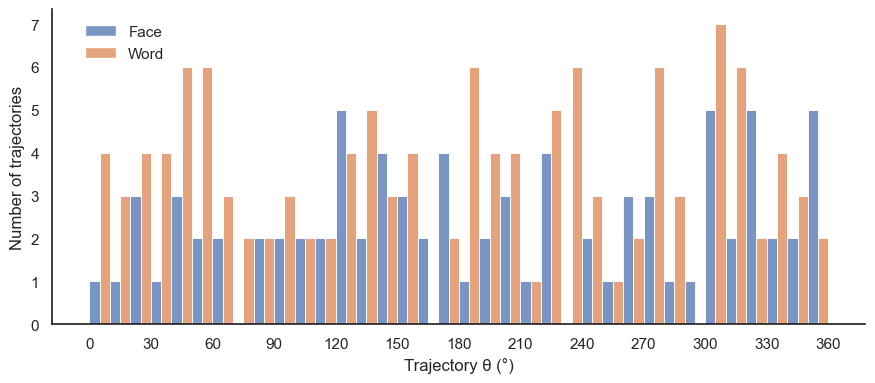

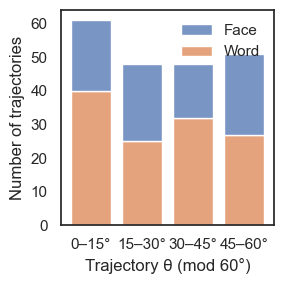

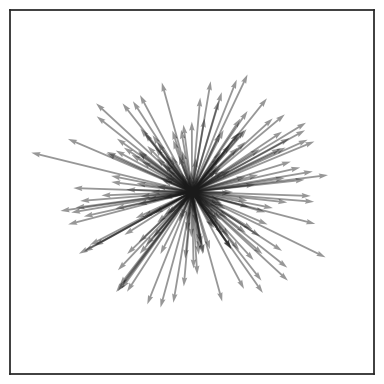

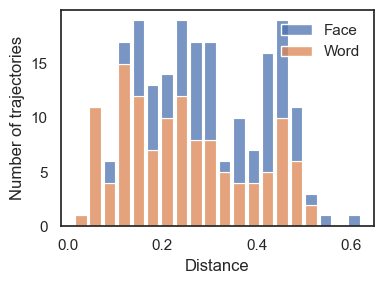

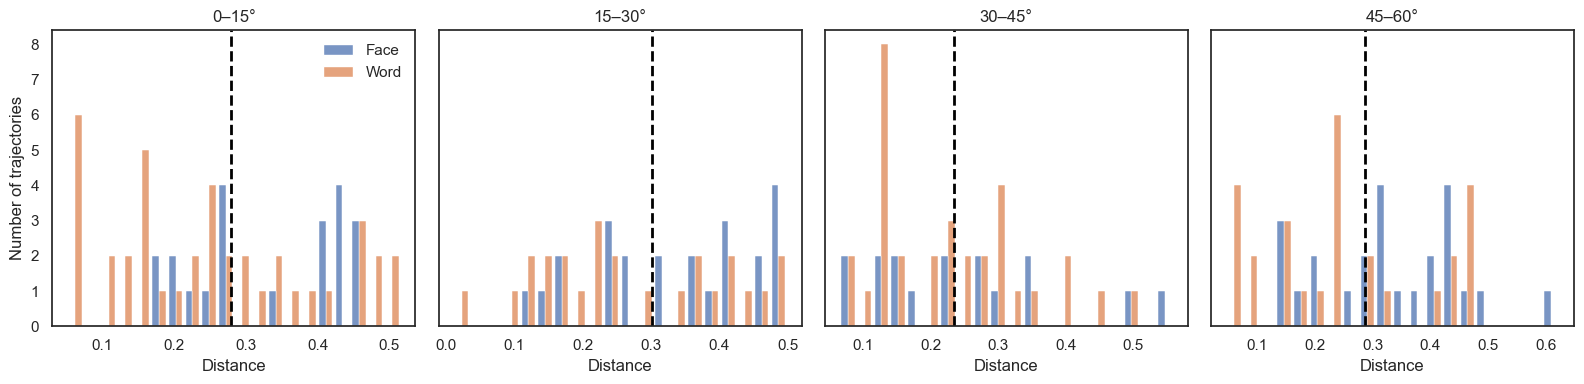

In [8]:
# Combine face and word trajectories
combined_traj = pd.concat([face_traj.assign(task='Face'), word_traj.assign(task='Word')], ignore_index=True)
angle_bins = np.arange(0, 370, 10)
sns.set(style="white")
plt.rcParams.update({'svg.fonttype': 'none', 'font.family': 'Arial', 'font.sans-serif': ['Arial']})
g = sns.displot(data=combined_traj, x="theta", hue="task", bins=angle_bins, multiple="dodge", stat="count", height=4, aspect=2)
g.set_axis_labels("Trajectory θ (°)", "Number of trajectories")
plt.xticks(np.arange(0, 361, 30))
g.legend.set_title(None)
g.legend.set_bbox_to_anchor((0.2, 0.85))
g.legend.set_title("")
plt.tight_layout()
#plt.savefig('./outputs/vector_plots/theta_distribution_360_mdscosineseedAvg.svg', dpi=600, bbox_inches='tight')
plt.show()


# Histogram of theta_bin_60
plt.figure(figsize=(3, 3))
ax = sns.histplot(data=combined_traj, x="theta_bin_60", hue="task", multiple="stack", stat="count", shrink=0.8)
plt.xlabel("Trajectory θ (mod 60°)"); plt.ylabel("Number of trajectories")
legend = ax.get_legend()
if legend: legend.set_title(""); legend.set_frame_on(False)
plt.tight_layout()
#plt.savefig('./outputs/vector_plots/theta_distribution_mod60.svg', dpi=600, bbox_inches='tight')
plt.show()


# Vector fan
plot_df = combined_traj.copy()
plot_df["theta_rad"] = np.deg2rad(plot_df["theta"])
plot_df["dx"] = plot_df["distance"] * np.cos(plot_df["theta_rad"])
plot_df["dy"] = plot_df["distance"] * np.sin(plot_df["theta_rad"])
max_distance = plot_df["distance"].max()
ring_values = np.linspace(max_distance / 4, max_distance, 4)
fig, ax = plt.subplots(figsize=(4,4))
q = ax.quiver(np.zeros(len(plot_df)), np.zeros(len(plot_df)), plot_df["dx"], plot_df["dy"],
              angles="xy", scale_units="xy", scale=1, alpha=0.45, width=0.005)
ax.set_aspect('equal')
ax.set_xlim(-max_distance*1.1, max_distance*1.1)
ax.set_ylim(-max_distance*1.1, max_distance*1.1)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
# remove x and y ticks
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

# Histogram of distance
plt.figure(figsize=(4, 3))
ax = sns.histplot(data=combined_traj, x="distance", hue="task", multiple="stack", bins=20, stat="count", shrink=0.8)
plt.xlabel("Distance"); plt.ylabel("Number of trajectories")
legend = ax.get_legend()
if legend: legend.set_title(""); legend.set_frame_on(False)
#y ticks should be 0 5 10 15 
ax.set_yticks([0, 5, 10, 15])
plt.tight_layout()
#plt.savefig('./outputs/vector_plots/distance_distribution.svg', dpi=600, bbox_inches='tight')
plt.show()

# Separate histogram of distance for each theta_bin_60
unique_bins = sorted(combined_traj['theta_bin_60'].unique(), key=lambda x: float(x) if str(x).replace('.','',1).isdigit() else x)
fig, axs = plt.subplots(1, len(unique_bins), figsize=(4*len(unique_bins), 4), sharey=True)
if len(unique_bins) == 1: axs = [axs]
for i, bin_val in enumerate(unique_bins):
    subset = combined_traj[combined_traj["theta_bin_60"] == bin_val]
    sns.histplot(data=subset, x="distance", hue="task", bins=20, stat="count", multiple="dodge", shrink=0.8, ax=axs[i])
    axs[i].set_title(f"{bin_val}"); axs[i].set_xlabel("Distance"); axs[i].set_ylabel("Number of trajectories")
    axs[i].axvline(subset["distance"].mean(), color='black', linestyle='--', linewidth=2)
for j, ax in enumerate(axs):
    legend = ax.get_legend()
    if legend: legend.set_title(""); legend.set_frame_on(False)
    if j > 0: ax.legend([], [], frameon=False)
plt.tight_layout(); plt.show()


In [9]:
from scipy.stats import chisquare

bin_order = ["0–15°", "15–30°", "30–45°", "45–60°"]
for task in ['Face', 'Word', 'Both']:
    task_data = combined_traj[combined_traj["task"] == task] if task != 'Both' else combined_traj
    obs = task_data["theta_bin_60"].value_counts().reindex(bin_order, fill_value=0)
    exp = np.full(len(bin_order), obs.sum() / len(bin_order))
    stat, p = chisquare(f_obs=obs, f_exp=exp)
    print(f"--------------------Task: {task}-----------------------")
    print("Observed counts:"); print(obs)
    print("Expected counts under uniformity:"); print(exp)
    print(f"χ²({len(bin_order)-1}) = {stat:.3f}, p = {p:.4f}")

import pingouin as pg

def run_rayleigh_test(data, theta_col="theta"):
    theta = data[theta_col].dropna().to_numpy()
    theta_folded_60 = np.mod(theta, 60)
    theta_sixfold_rad = np.deg2rad(theta_folded_60 * 6)
    z, p = pg.circ_rayleigh(theta_sixfold_rad)

    # Circular mean direction, converted back to the 0–60° cycle
    mean_direction_sixfold = np.angle(np.mean(np.exp(1j * theta_sixfold_rad))) % (2 * np.pi)
    mean_direction_60 = np.rad2deg(mean_direction_sixfold) / 6
    mean_resultant_length = np.abs(np.mean(np.exp(1j * theta_sixfold_rad)))

    return pd.Series({
        "n": len(theta),
        "rayleigh_z": z,
        "rayleigh_p": p,
        "mean_direction_60": mean_direction_60,
        "mean_resultant_length": mean_resultant_length})
print("-------------Face & Word------------------------------")
results_by_task = combined_traj.groupby("task").apply(run_rayleigh_test).reset_index()
print(results_by_task)
print("--------------Both modalities-------------------------")
print(run_rayleigh_test(combined_traj))


print("===================================================================================")
import statsmodels.api as sm
from statsmodels.formula.api import ols
print("Distance ANOVA for both modalities:")
distance_model = ols("distance ~ C(theta_bin_60)",data=combined_traj).fit()
distance_anova = sm.stats.anova_lm(distance_model,typ=2)
print(distance_anova)

for task in combined_traj["task"].unique():
    task_data = combined_traj[combined_traj["task"] == task]
    distance_model = ols("distance ~ C(theta_bin_60)", data=task_data).fit()
    distance_anova = sm.stats.anova_lm(distance_model, typ=2)
    print(f"\nDistance ANOVA for {task}:")
    print(distance_anova)

theta_rad = np.deg2rad(combined_traj["theta"])
combined_traj["sin6theta"] = np.sin(6 * theta_rad)
combined_traj["cos6theta"] = np.cos(6 * theta_rad)
print("-----------Sixfold continuous-angle model for both modalities:-----------")

distance_model = ols("distance ~ sin6theta + cos6theta",data=combined_traj).fit()
print(distance_model.summary())
sixfold_test = distance_model.f_test("sin6theta = 0, cos6theta = 0")
print("\nJoint sixfold test:")
print(sixfold_test)
F_value = float(sixfold_test.fvalue)
df_num = float(sixfold_test.df_num)
df_denom = float(sixfold_test.df_denom)
partial_eta_sq = (F_value * df_num / (F_value * df_num + df_denom))
print(f"Partial eta squared = {partial_eta_sq:.4f}")

--------------------Task: Face-----------------------
Observed counts:
theta_bin_60
0–15°     21
15–30°    23
30–45°    16
45–60°    24
Name: count, dtype: int64
Expected counts under uniformity:
[21. 21. 21. 21.]
χ²(3) = 1.810, p = 0.6129
--------------------Task: Word-----------------------
Observed counts:
theta_bin_60
0–15°     40
15–30°    25
30–45°    32
45–60°    27
Name: count, dtype: int64
Expected counts under uniformity:
[31. 31. 31. 31.]
χ²(3) = 4.323, p = 0.2287
--------------------Task: Both-----------------------
Observed counts:
theta_bin_60
0–15°     61
15–30°    48
30–45°    48
45–60°    51
Name: count, dtype: int64
Expected counts under uniformity:
[52. 52. 52. 52.]
χ²(3) = 2.192, p = 0.5335
-------------Face & Word------------------------------
   task      n  rayleigh_z  rayleigh_p  mean_direction_60  \
0  Face   84.0    0.006213    0.993843          53.644232   
1  Word  124.0    0.276929    0.758836           9.433431   

   mean_resultant_length  
0             

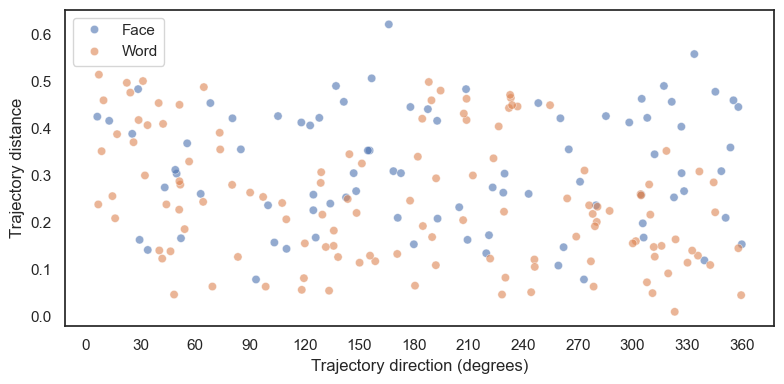

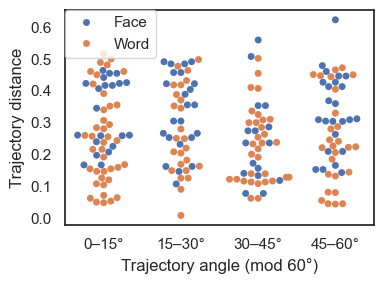

In [65]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=combined_traj, x="theta", y="distance", hue="task", alpha=0.6)
plt.xlabel("Trajectory direction (degrees)"); plt.ylabel("Trajectory distance")
plt.xticks(np.arange(0, 361, 30)); plt.legend(title=None)
plt.tight_layout(); plt.show()

plt.figure(figsize=(4, 3))
g = sns.swarmplot(data=combined_traj, x="theta_bin_60", y="distance", hue="task", dodge=False)
g.legend(title="", loc="upper left", bbox_to_anchor=(0,1), borderaxespad=0)
mean_distance = combined_traj.groupby("theta_bin_60")["distance"].mean()
#plt.scatter(mean_distance.index, mean_distance.values, color='black', marker='o', s=100, label='Mean distance')
#plt.plot(mean_distance.index, mean_distance.values, color='black', linestyle='--', linewidth=2, label='Mean distance line')
plt.xlabel("Trajectory angle (mod 60°)"); plt.ylabel("Trajectory distance")
plt.tight_layout(); plt.savefig('./outputs/vector_plots/distance_by_theta_mod60_mdscosineseedAvg.svg',bbox_inches='tight')
plt.show()

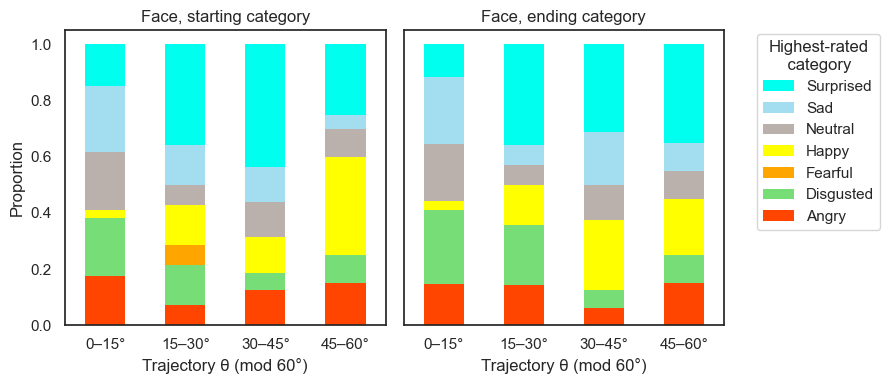

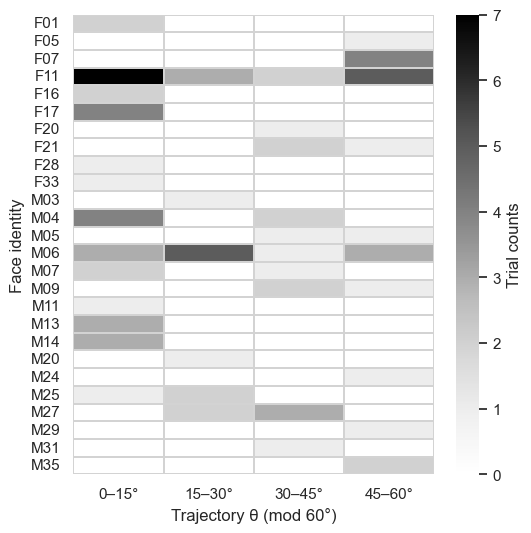

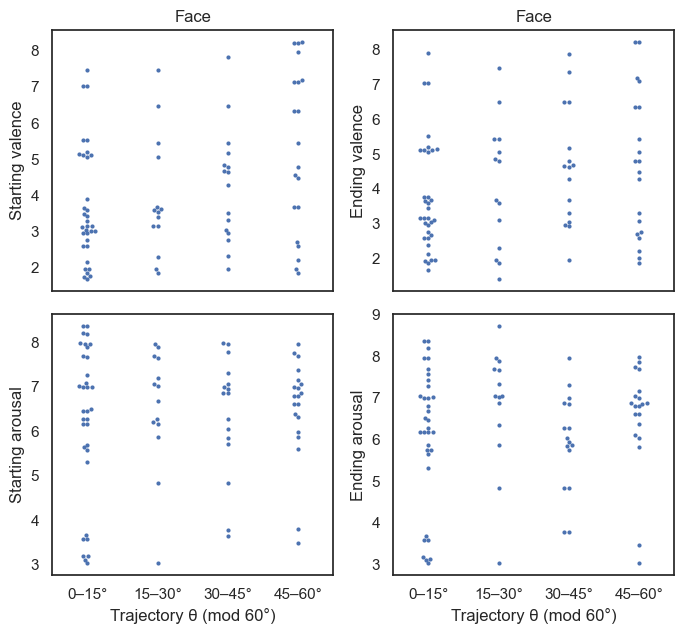

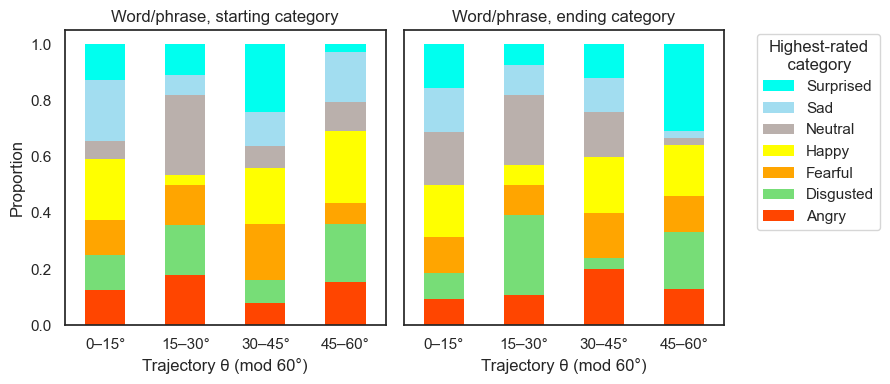

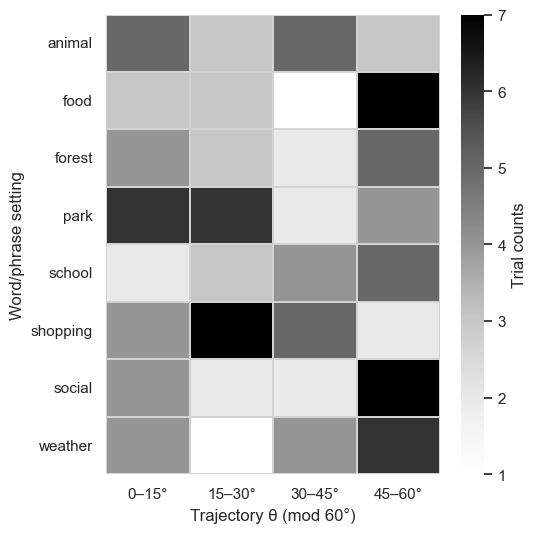

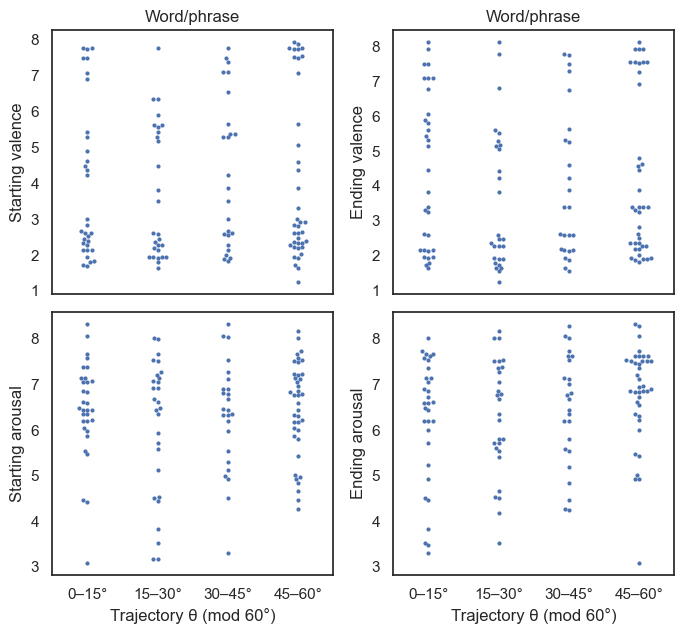

In [10]:
plot_category_panels(face_traj, "Face",category_colors, save_svg=True,save=f'./outputs/vector_plots/theta_by_category_face.svg')
plot_identity_heatmap(face_traj, "Face", save_svg=True,save=f'./outputs/vector_plots/theta_by_group_face.svg')
plot_val_arousal(face_traj, "Face", save_svg=True,save=f'./outputs/vector_plots/theta_by_va_face.svg')

plot_category_panels(word_traj, "Word/phrase",category_colors, save_svg=True,save=f'./outputs/vector_plots/theta_by_category_word.svg')
plot_identity_heatmap(word_traj, "Word/phrase", save_svg=True,save=f'./outputs/vector_plots/theta_by_group_word.svg')
plot_val_arousal(word_traj, "Word/phrase", save_svg=True,save=f'./outputs/vector_plots/theta_by_va_word.svg')

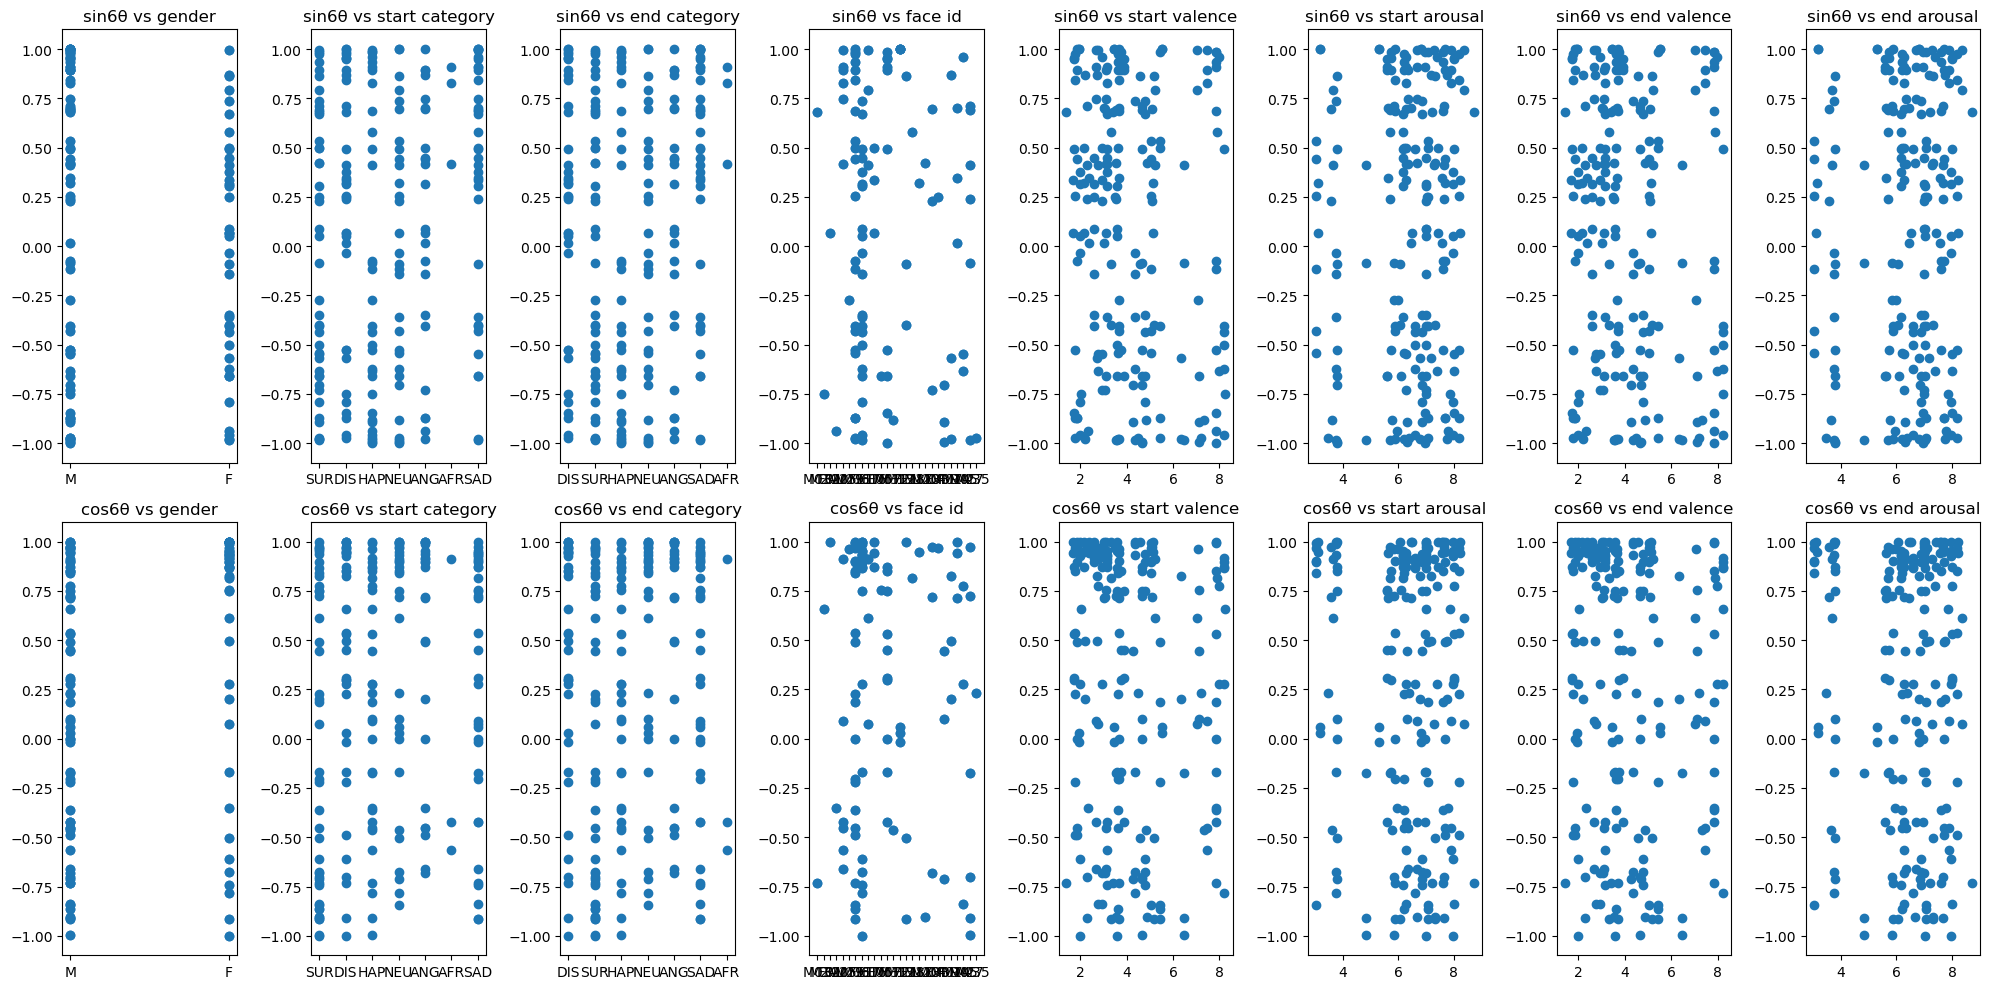

<Figure size 640x480 with 0 Axes>

In [4]:
face_traj['sin6θ'] = np.sin(np.radians(6*face_traj['theta']))
face_traj['cos6θ'] = np.cos(np.radians(6*face_traj['theta']))


fig, axs = plt.subplots(2, 8, figsize=(20, 10))
titles = ['gender', 'start category', 'end category', 'face id', 'start valence', 'start arousal', 'end valence', 'end arousal']
columns = ['gender', 'max_start_category', 'max_end_category', 'group', 'start_valence', 'start_arousal', 'end_valence', 'end_arousal']

for i, title, column in zip(range(8), titles, columns):
    axs[0, i].plot(face_traj[column], face_traj['sin6θ'], 'o')
    axs[0, i].set_title(f'sin6θ vs {title}')
    axs[1, i].plot(face_traj[column], face_traj['cos6θ'], 'o')
    axs[1, i].set_title(f'cos6θ vs {title}')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

X_vars = {
    'sin6θ': face_traj[['sin6θ']], 
    'cos6θ': face_traj[['cos6θ']], 
    'sin6θ + cos6θ': face_traj[['sin6θ', 'cos6θ']]
}
r2_results = {key: {} for key in X_vars}

for column in columns[0:8]:
    # convert categorical variables to numbers if needed
    y = LabelEncoder().fit_transform(face_traj[column]) if face_traj[column].dtype == 'object' else face_traj[column]
    
    for key, X in X_vars.items():
        model = LinearRegression().fit(X, y)
        r2_results[key][column] = r2_score(y, model.predict(X))
        print(f"R² (variance explained by {key}) for {column}: {r2_results[key][column] * 100:.2f}%")
print('---------------------------------------------------------')
for column in columns[8:26]:
    # convert categorical variables to numbers if needed
    y = LabelEncoder().fit_transform(face_traj[column]) if face_traj[column].dtype == 'object' else face_traj[column]
    
    for key, X in X_vars.items():
        model = LinearRegression().fit(X, y)
        r2_results[key][column] = r2_score(y, model.predict(X))
        print(f"R² (variance explained by {key}) for {column}: {r2_results[key][column] * 100:.2f}%")

R² (variance explained by sin6θ) for gender: 1.51%
R² (variance explained by cos6θ) for gender: 5.79%
R² (variance explained by sin6θ + cos6θ) for gender: 6.94%
R² (variance explained by sin6θ) for max_start_category: 0.19%
R² (variance explained by cos6θ) for max_start_category: 3.00%
R² (variance explained by sin6θ + cos6θ) for max_start_category: 3.31%
R² (variance explained by sin6θ) for max_end_category: 0.19%
R² (variance explained by cos6θ) for max_end_category: 3.00%
R² (variance explained by sin6θ + cos6θ) for max_end_category: 3.31%
R² (variance explained by sin6θ) for group: 1.96%
R² (variance explained by cos6θ) for group: 6.60%
R² (variance explained by sin6θ + cos6θ) for group: 8.12%
R² (variance explained by sin6θ) for start_valence: 1.80%
R² (variance explained by cos6θ) for start_valence: 0.61%
R² (variance explained by sin6θ + cos6θ) for start_valence: 2.57%
R² (variance explained by sin6θ) for start_arousal: 0.24%
R² (variance explained by cos6θ) for start_arousal: 0

#### Aligned vs. misaligned 

In [53]:
cross_validations = ["xModalityRun", "xModality"]
value_factors = ["start_valence_difference", "start_arousal_difference", "end_valence_difference", "end_arousal_difference", "trajectory_length_difference", "valence_displacement_difference", "arousal_displacement_difference", "same_start", "same_end", "same_id", "same_response", 'pattern_similarity']

data_all = []
for cross_validation in cross_validations:
    data = pd.read_csv(f"./outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/onoffGridcontrast_multivariate_wMoreControls/unsmoothed/Subavg/periodicity6/{cross_validation}/phi_voxelComponentAverage/singleTrialBeta/csv/design_tbl_va_cat_id_response.csv")
    available_factors = [col for col in value_factors if col in data.columns]
    data = data.groupby(["region", "subject", "test_runs", "alignment"], as_index=False)[available_factors].mean().groupby(["region", "subject", "alignment"], as_index=False)[available_factors].mean()
    data["cross_validation"] = cross_validation
    data_all.append(data)

data_all = pd.concat(data_all, ignore_index=True)
data_all = data_all[data_all["region"] == "OFC2016ConstantinescuR5"].copy()

available_factors = [col for col in value_factors if col in data_all.columns]

data_avg = data_all.groupby(["region", "subject", "alignment"], as_index=False)[available_factors].mean()
data_avg["alignment_label"] = data_avg["alignment"].map({1: "Aligned", 0: "Misaligned"})

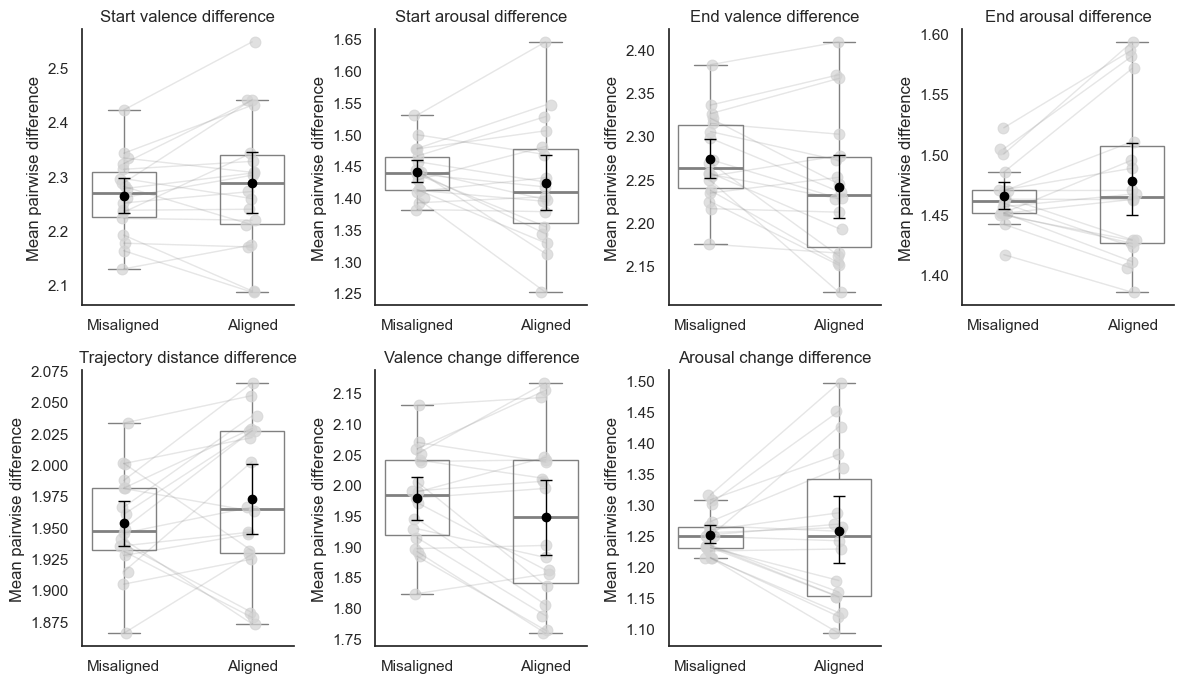

In [58]:
# Define factor labels, keep if present
continuous_factors = {k: v for k, v in {
    "start_valence_difference": "Start valence difference",
    "start_arousal_difference": "Start arousal difference",
    "end_valence_difference": "End valence difference",
    "end_arousal_difference": "End arousal difference",
    "trajectory_length_difference": "Trajectory distance difference",
    "valence_displacement_difference": "Valence change difference",
    "arousal_displacement_difference": "Arousal change difference",
   # "pattern_similarity": "Pattern similarity",
}.items() if k in data_avg.columns}

data_avg["alignment_label"] = data_avg["alignment"].map({1: "Aligned", 0: "Misaligned"})

continuous_long = data_avg.melt(
    id_vars=["subject", "alignment", "alignment_label"],
    value_vars=list(continuous_factors),
    var_name="factor", value_name="value"
)
continuous_long["factor_label"] = continuous_long["factor"].map(continuous_factors)

n = len(continuous_factors)
n_cols = 4
n_rows = int(np.ceil(n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows), squeeze=False)
axes = axes.ravel()

for ax, (factor, label) in zip(axes, continuous_factors.items()):
    data_to_plot = continuous_long.loc[continuous_long["factor"] == factor, ["subject", "alignment_label", "value"]].dropna()
    stats_df_to_plot = bootstrap_ci(data_to_plot, target_col="value", group_vars=["alignment_label"])
    plot_subjectConnected_performance_scatter_wbox(
        data_to_plot, "alignment_label", "value", "subject", stats_df_to_plot, title=label,
        condition_order=["Misaligned", "Aligned"], condition_labels=["Misaligned", "Aligned"],
        fill_colors=['lightgray', 'lightgray'], connect_subjects=True, plot_box=True, plot_bar=False, box_edgecolor="gray",
        line_alpha=0.1, 
        errorbar_color="black", figsize=(3.5, 3.5), ylabel="Mean pairwise difference", xlabel="", jitter=0.02, ax=ax, 
        #save_svg=True, save=f'./outputs/vector_plots/confounding_factors_continuous_aligned_vs_misaligned_OFC2016ConstantinescuR5_6fold_subavg_5000repeats.svg'
    )
[ax.remove() for ax in axes[n:]]
plt.tight_layout()
plt.savefig('./outputs/vector_plots/confounding_factors_continuous_aligned_vs_misaligned_OFC2016ConstantinescuR5_6fold_subavg_5000repeats.svg', bbox_inches='tight')
plt.show()

In [92]:
continuous_long[continuous_long["factor"] == "pattern_similarity"]
# Get average across subjects for each alignment specifically for pattern_similarity
pattern_similarity_avg = continuous_long[continuous_long["factor"] == "pattern_similarity"].groupby("alignment_label")["value"].mean()
print(pattern_similarity_avg)


alignment_label
Aligned       0.080059
Misaligned    0.072894
Name: value, dtype: float64


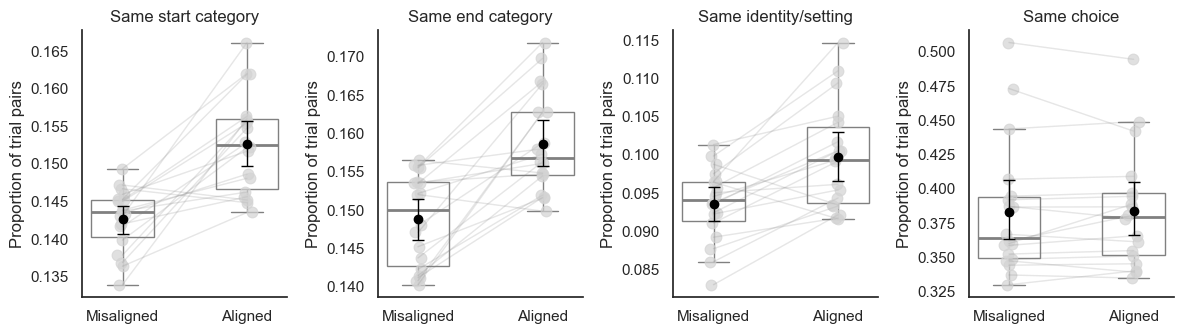

In [66]:
binary_factors = {
    "same_start": "Same start category",
    "same_end": "Same end category",
    "same_id": "Same identity/setting",
    "same_response": "Same choice",
}
binary_long = data_avg.melt(
    id_vars=["subject", "alignment", "alignment_label"],
    value_vars=list(binary_factors),
    var_name="factor",
    value_name="proportion",
)
binary_long["factor_label"] = binary_long["factor"].map(binary_factors)
n = len(binary_factors)
n_cols = 4
n_rows = int(np.ceil(n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows), squeeze=False)
axes = axes.ravel()
for ax, (factor, label) in zip(axes, binary_factors.items()):
    data_to_plot = binary_long.loc[binary_long["factor"] == factor, ["subject", "alignment_label", "proportion"]].dropna()
    stats_df_to_plot = bootstrap_ci(data_to_plot, target_col="proportion", group_vars=["alignment_label"])
    plot_subjectConnected_performance_scatter_wbox(
        data_to_plot, "alignment_label", "proportion", "subject", stats_df_to_plot, title=label,
        condition_order=["Misaligned", "Aligned"], condition_labels=["Misaligned", "Aligned"],
        fill_colors=['lightgray', 'lightgray'], connect_subjects=True, plot_box=True, plot_bar=False, box_edgecolor="gray",
        line_alpha=0.1,
        errorbar_color="black", figsize=(4, 3.5), ylabel="Proportion of trial pairs", xlabel="", dotted_yline=None,
        jitter=0.02, ax=ax, #yrange=(0, 0.), 
        save_svg=True, save=f'./outputs/vector_plots/confounding_factors_binary_aligned_vs_misaligned_OFC2016ConstantinescuR5_6fold_subavg_5000repeats.svg'
    )
[ax.remove() for ax in axes[n:]]
plt.tight_layout()
plt.show()

In [64]:
all_factors = list(continuous_factors) + list(binary_factors)
difference_rows = [(data_avg.pivot(index="subject", columns="alignment", values=factor)
        .dropna(subset=[0, 1])
        .assign(factor=factor, difference=lambda df: df[1] - df[0])[["factor", "difference"]]
        .reset_index())
    for factor in all_factors if factor in data_avg.columns]
factor_differences = pd.concat(difference_rows, ignore_index=True)
print(bootstrap_ci(data=factor_differences, target_col="difference", group_vars=["factor"]).merge(sign_flip_permutation(data=factor_differences, target_col="difference", group_vars=["factor"]), on="factor").to_string())

                             factor      mean  ci_lower  ci_upper         d  test_stat     p_val
0   arousal_displacement_difference  0.006082 -0.034265  0.050086  0.066388   0.006082  0.392761
1            end_arousal_difference  0.012239 -0.007596  0.033114  0.275987   0.012239  0.130287
2            end_valence_difference -0.032592 -0.055925 -0.009723 -0.658225  -0.032592  0.992001
3                pattern_similarity  0.007165  0.003104  0.011626  0.784457   0.007165  0.001400
4                          same_end  0.009875  0.006450  0.013327  1.327705   0.009875  0.000100
5                           same_id  0.006077  0.003490  0.008594  1.106797   0.006077  0.000200
6                     same_response  0.000863 -0.004813  0.006405  0.070724   0.000863  0.392861
7                        same_start  0.009998  0.006560  0.013473  1.346582   0.009998  0.000100
8          start_arousal_difference -0.018568 -0.051226  0.013971 -0.265203  -0.018568  0.860114
9          start_valence_diffe

In [3]:
output_dir = "./outputs/matched_confounding_factors_analysis/5000repeats/"
prefix = "OFC2016ConstantinescuR5_6fold_subavg_exact_continuous_matching"

subject_repeat_contrasts = pd.read_csv(f"{output_dir}/{prefix}_subject_contrasts_by_repeat.csv")
factor_balance_subject = pd.read_csv(f"{output_dir}/{prefix}_confound_balance_subject_by_repeat.csv")
factor_balance_repeat = pd.read_csv(f"{output_dir}/{prefix}_confound_balance_group_by_repeat.csv")
factor_balance_across_repeats = pd.read_csv(f"{output_dir}/{prefix}_confound_balance_across_repeats.csv")
subject_matched_contrasts = pd.read_csv(f"{output_dir}/{prefix}_subject_contrasts_averaged.csv")
matched_stats = pd.read_csv(f"{output_dir}/{prefix}_group_statistics.csv")

group_repeat_contrasts = subject_repeat_contrasts.groupby(["region", "repeat"], as_index=False).agg(
    group_mean_difference=("pattern_similarity_difference", "mean"),
    n_subjects=("subject", "nunique"),
)
mean_difference = group_repeat_contrasts["group_mean_difference"].mean()


In [9]:
subject_repeat_contrasts_avg = subject_repeat_contrasts.groupby(["region", "subject"], as_index=False).agg(
    group_mean_difference=("pattern_similarity_difference", "mean"),
    n_subjects=("subject", "nunique"),
)
subject_repeat_contrasts_avg

,region,subject,group_mean_difference,n_subjects
0,OFC2016ConstantinescuR5,1,0.016788,1
1,OFC2016ConstantinescuR5,2,0.003267,1
2,OFC2016ConstantinescuR5,3,0.003797,1
3,OFC2016ConstantinescuR5,4,0.017714,1
4,OFC2016ConstantinescuR5,7,0.012417,1
5,OFC2016ConstantinescuR5,8,0.010642,1
6,OFC2016ConstantinescuR5,9,-0.001784,1
7,OFC2016ConstantinescuR5,10,-0.006558,1
8,OFC2016ConstantinescuR5,11,0.008407,1
9,OFC2016ConstantinescuR5,12,0.002086,1


In [13]:
print(stats_df_to_plot)

                    region      mean  ci_lower  ci_upper         d
0  OFC2016ConstantinescuR5  0.006229   0.00222  0.010609  0.681787


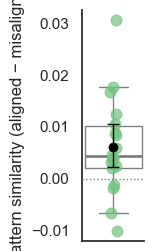

In [26]:
subject_repeat_contrasts
#average across repeats for each subject
subject_repeat_contrasts_avg = subject_repeat_contrasts.groupby(["region", "subject"], as_index=False).agg(
    group_mean_difference=("pattern_similarity_difference", "mean"),
    n_subjects=("subject", "nunique"),
)
stats_df_to_plot = bootstrap_ci(subject_repeat_contrasts_avg, "group_mean_difference", ["region"])
plot_subjectConnected_performance_scatter_wbox(
        subject_repeat_contrasts_avg, "region", "group_mean_difference", "subject", stats_df_to_plot, title="",
        condition_order=["OFC2016ConstantinescuR5"], condition_labels=[""], fill_colors=['#70c17f'],
        connect_subjects=True, plot_box=True, plot_bar=False, box_edgecolor="gray", errorbar_color="black",
        figsize=(0.8, 3), ylabel="Δ Pattern similarity (aligned − misaligned)", xlabel="", dotted_yline=0, jitter=0.02,
        line_alpha=0.1,
        save_svg=True, save=f'./outputs/vector_plots/matched_binary_confounding_group_contrast_avg_OFC2016ConstantinescuR5_6fold_subavg_5000repeats.svg'
    )

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


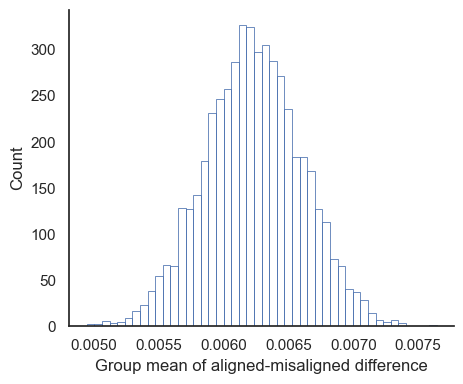

0.004942382813977055 0.007641752209546277 0.006229163368342996
                    region      mean  ci_lower  ci_upper         d  test_stat     p_val
0  OFC2016ConstantinescuR5  0.006229   0.00222  0.010609  0.681787   0.006229  0.007599


In [ ]:
sns.set_style("white")
plt.rcParams['svg.fonttype'] = 'none'   
plt.rcParams["font.family"] = "Arial"

g = sns.displot(data=group_repeat_contrasts, x="group_mean_difference", ax=ax, fill=False, common_norm=False, height=4, aspect=1.2, legend=False)
g.set_axis_labels("Group mean of aligned-misaligned difference", "Count")
ax.legend(frameon=False)
plt.savefig('./outputs/vector_plots/matched_binary_confounding_group_contrast_distribution_OFC2016ConstantinescuR5_6fold_subavg_5000repeats.svg', bbox_inches='tight')
plt.tight_layout()
plt.show()
print(group_repeat_contrasts['group_mean_difference'].min(), group_repeat_contrasts['group_mean_difference'].max(), group_repeat_contrasts['group_mean_difference'].mean())
print(matched_stats.to_string())

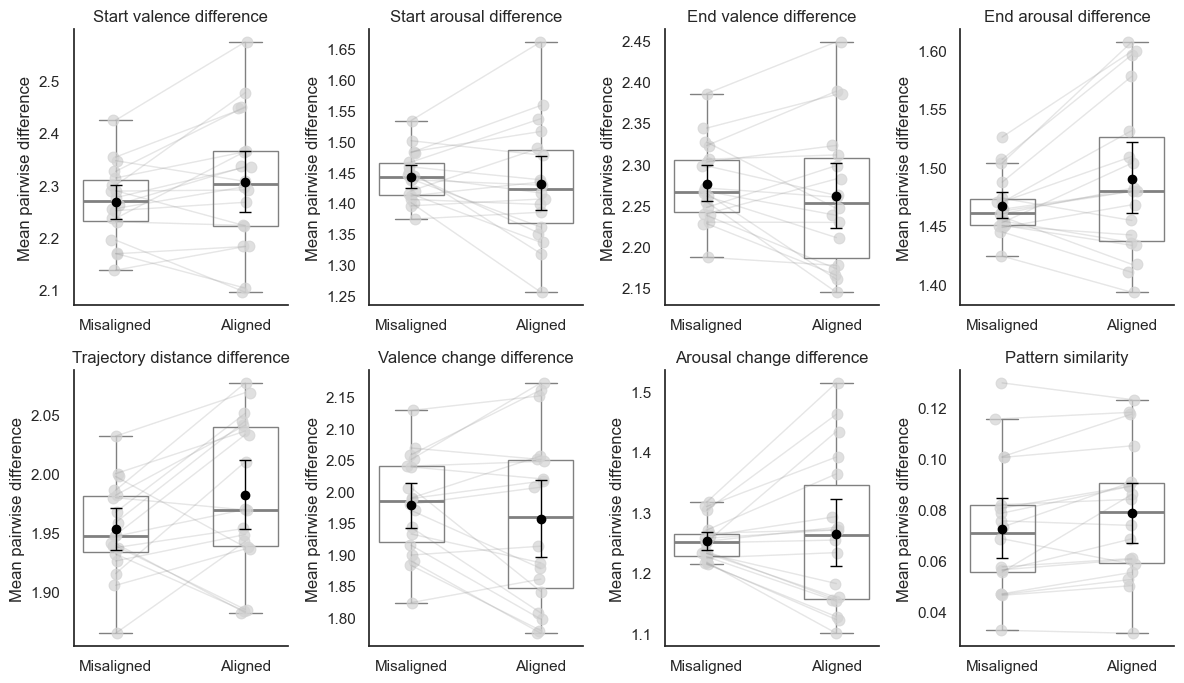

In [61]:
# Aggregate subject averages, melt, and relabel alignment in fewer lines
factor_subject_average = factor_balance_subject.groupby(
    ["region", "subject", "factor", "factor_type"], as_index=False
).agg(
    aligned_mean=("aligned_mean", "mean"),
    misaligned_mean=("misaligned_mean", "mean"),
    mean_difference=("difference", "mean"),
    mean_smd=("smd", "mean"),
)
factor_long = factor_subject_average.melt(
    id_vars=["region", "subject", "factor", "factor_type"],
    value_vars=["misaligned_mean", "aligned_mean"],
    var_name="alignment_label", value_name="value"
)
factor_long["alignment_label"] = factor_long["alignment_label"].map(
    {"misaligned_mean": "Misaligned", "aligned_mean": "Aligned"}
)
continuous_factors = {k: v for k, v in {
    "start_valence_difference": "Start valence difference",
    "start_arousal_difference": "Start arousal difference",
    "end_valence_difference": "End valence difference",
    "end_arousal_difference": "End arousal difference",
    "trajectory_length_difference": "Trajectory distance difference",
    "valence_displacement_difference": "Valence change difference",
    "arousal_displacement_difference": "Arousal change difference",
    "pattern_similarity": "Pattern similarity",
}.items()}
continuous_long = factor_long[factor_long["factor_type"] == "continuous"].copy()
n = len(continuous_factors)
num_cols = 4
num_rows = int(np.ceil(n / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 3.5 * num_rows), squeeze=False)
axes = axes.ravel()

for ax, (factor, label) in zip(axes, continuous_factors.items()):
    data_to_plot = continuous_long.query("factor == @factor")[["subject", "alignment_label", "value"]].dropna()
    stats_df_to_plot = bootstrap_ci(data_to_plot, target_col="value", group_vars=["alignment_label"])
    plot_subjectConnected_performance_scatter_wbox(
        data_to_plot, "alignment_label", "value", "subject", stats_df_to_plot, title=label,
        condition_order=["Misaligned", "Aligned"], condition_labels=["Misaligned", "Aligned"], fill_colors=['lightgray', 'lightgray'],
        connect_subjects=True, plot_box=True, plot_bar=False, box_edgecolor="gray", errorbar_color="black",
        figsize=(4.2, 4.2), ylabel="Mean pairwise difference", xlabel="", dotted_yline=None, jitter=0.02,
        line_alpha=0.1,
        ax=ax, save_svg=False
    )

[ax.remove() for ax in axes[n:]]
plt.tight_layout()
plt.show()

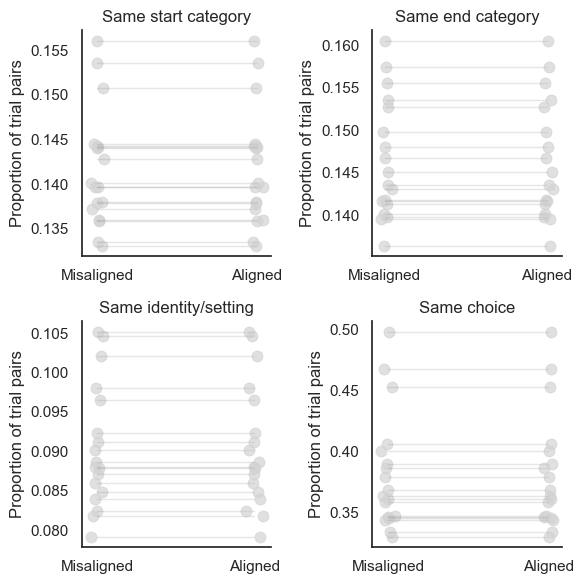

In [72]:
binary_factors = {
    "same_start": "Same start category",
    "same_end": "Same end category",
    "same_id": "Same identity/setting",
    "same_response": "Same choice"
}

binary_long = factor_long[factor_long["factor_type"] == "discrete"].rename(columns={"value": "proportion"}).copy()
n = len(binary_factors)
fig, axes = plt.subplots(int(np.ceil(n/2)), 2, figsize=(6, 3*np.ceil(n/2)), squeeze=False)

axes = axes.ravel()

for ax, (factor, label) in zip(axes, binary_factors.items()):
    data_to_plot = binary_long.loc[binary_long["factor"] == factor, ["subject", "alignment_label", "proportion"]].dropna()
    stats_df_to_plot = bootstrap_ci(data_to_plot, "proportion", ["alignment_label"])
    plot_subjectConnected_performance_scatter_wbox(
        data_to_plot, "alignment_label", "proportion", "subject", stats_df_to_plot, 
        title=label,
        condition_order=["Misaligned", "Aligned"], condition_labels=["Misaligned", "Aligned"],
        fill_colors=['lightgray', 'lightgray'], connect_subjects=True, plot_box=False, plot_bar=False,
        box_edgecolor="gray", errorbar_color="black", figsize=(5.2, 4.2), ylabel="Proportion of trial pairs",
        line_alpha=0.1,plot_ci=False,
        xlabel="", dotted_yline=None, jitter=0.02, ax=ax, #yrange=(0, 1), 
        save_svg=False
    )
[ax.remove() for ax in axes[n:]]
plt.tight_layout()
plt.savefig('./outputs/vector_plots/matched_confounding_factors_binary_aligned_vs_misaligned_OFC2016ConstantinescuR5_6fold_subavg_5000repeats.svg', bbox_inches='tight')
plt.show()

In [29]:
all_factors = [*continuous_factors, *binary_factors]
factor_differences = (factor_balance_subject.query("factor in @all_factors")
    .groupby(["region", "subject", "factor"], as_index=False)
    .agg({k: "mean" for k in ["difference", "aligned_mean", "misaligned_mean", "smd"]})
    .rename(columns={"smd": "mean_smd"}))
factor_ci = bootstrap_ci(factor_differences, "difference", ["factor"], 10000, 0.95, 42)
factor_tests = sign_flip_permutation(factor_differences, "difference", ["factor"], 10000, 200, "two-sided", True)
stats_summary = (factor_ci
    .merge(factor_tests, on="factor")
    .merge(
        factor_differences.groupby("factor", as_index=False).agg(
            aligned_mean=("aligned_mean", "mean"),
            misaligned_mean=("misaligned_mean", "mean"),
            mean_smd=("mean_smd", "mean"),
            n_subjects=("subject", "nunique")), 
        on="factor"))
stats_summary["factor_label"] = stats_summary["factor"].map({**continuous_factors, **binary_factors})
cols = ["factor", "factor_label", "aligned_mean", "misaligned_mean", "mean", "ci_lower", "ci_upper", "mean_smd", "d", "test_stat", "p_val", "bonferroni_p_val", "n_subjects"]
print(stats_summary[cols].rename(columns={"mean": "mean_difference"}).round(6).to_string(index=False))

                         factor                 factor_label  aligned_mean  misaligned_mean  mean_difference  ci_lower  ci_upper  mean_smd         d  test_stat    p_val  bonferroni_p_val  n_subjects
arousal_displacement_difference    Arousal change difference      1.264641         1.251967         0.012674 -0.028870  0.057659 -0.007554  0.134572   0.012674 0.584542          1.000000          18
         end_arousal_difference       End arousal difference      1.490109         1.467192         0.022917  0.002279  0.044243  0.015284  0.504106   0.022917 0.051895          0.622738          18
         end_valence_difference       End valence difference      2.261105         2.276143        -0.015038 -0.040740  0.009774 -0.012368 -0.276320  -0.015038 0.272373          1.000000          18
             pattern_similarity           Pattern similarity      0.078690         0.072461         0.006229  0.002174  0.010671  0.023989  0.683703   0.006229 0.006299          0.075592          18
     

### Category & valence-arousal

In [4]:
def plot_mds_stimuli(
    rating_df, modality, categories,
    colors=None, cate_name_map=None, title='',
    fontsize=12, figsize=(8, 6), ax=None,
    if_legend=True, save=None, random_state=42,
    align_to_va=False,report_procrustes=False,
    report_stress=False, report_stress_save=None,
    save_svg=False
):
    sns.set(style="white")
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams['font.sans-serif'] = ['Arial']

    rating_df = rating_df.copy()
    rating_df['max_category'] = rating_df['max_category'].map(cate_name_map)

    rating_cols = [f'{modality}_{cat}_slider.response_mean' for cat in categories]
    X = rating_df[rating_cols].values
    valid_mask = ~np.isnan(X).any(axis=1)
    rating_df = rating_df[valid_mask]
    X = X[valid_mask]

    dissimilarity = pairwise_distances(X, metric='cosine')
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=random_state)
    coords = mds.fit_transform(dissimilarity)

    if report_stress == True:
        stress_values = []
        dimensions = [1, 2, 3, 4, 5]
        for d in dimensions:
            mds_d = MDS(n_components=d, dissimilarity='precomputed', random_state=random_state)
            coords_d = mds_d.fit_transform(dissimilarity)
            stress_raw = mds_d.stress_
            kruskal_stress = np.sqrt(stress_raw/(0.5* (dissimilarity**2).sum()))
            print(f"D = {d}: Stress: {stress_raw}, Kruskal Stress: {kruskal_stress}")
            stress_values.append(kruskal_stress)
        plt.figure(figsize=(6, 4))
        plt.plot(dimensions, stress_values, 'o-')
        plt.xlabel('Number of dimensions')#, weight='bold')
        plt.ylabel('Stress')#,  weight='bold')
        plt.xticks(dimensions)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        if report_stress_save is not None:
            if save_svg:
                plt.savefig(report_stress_save, format='svg', bbox_inches='tight')
            else:
                plt.savefig(report_stress_save, dpi=600)


    if report_procrustes:
        va = rating_df[[f'{modality}_v_slider.response_mean',f'{modality}_a_slider.response_mean']].values
        coords = [[coords[i, 0], coords[i, 1]] for i in range(len(coords))]

        observed, perm, p = procrustes_alignment_test(coords, va, rating_df['max_category'].values, n_permutations=100000, shuffle_within_category=False)
        print(f"Observed Procrustes distance = {observed:.3f}")
        print(f"Mean shuffled distance = {perm.mean():.3f} ± {perm.std():.3f}")
        print(f"p = {p:.4f}")

    #Optional alignment to valence-arousal space 
    if align_to_va:
        va = rating_df[[f'{modality}_v_slider.response_mean',
                        f'{modality}_a_slider.response_mean']].values
        va = (va - np.mean(va, axis=0)) / np.std(va, axis=0)
        coords_norm = (coords - np.mean(coords, axis=0)) / np.std(coords, axis=0)
        mtx1, mtx2, disparity = procrustes(va, coords_norm)
        coords = mtx2  # aligned version


    rating_df['mds_x'] = coords[:, 0]
    rating_df['mds_y'] = coords[:, 1]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.scatterplot(data=rating_df, x='mds_x', y='mds_y',hue='max_category', palette=colors if colors else 'Set2',s=60, edgecolor='k', ax=ax)

    ax.set_title(title, fontsize=fontsize)#,weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    #make the box square
    #ax.set_aspect('equal', 'box')   
    
    #set the thickness of the boundary
    ax.spines['left'].set_linewidth(1)
    ax.spines['right'].set_linewidth(1)
    ax.spines['top'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)

    if if_legend:
        ax.legend(title='Highest-rated\n   category',bbox_to_anchor=(1.05, 1), loc='upper left',title_fontsize=fontsize, fontsize=fontsize)
    else:
        ax.legend().remove()

    plt.tight_layout()
    if save is not None:
        if save_svg:
            plt.savefig(save, format='svg', bbox_inches='tight')
        else:
            plt.savefig(save, dpi=600)

    if ax is None:
        plt.show()

def procrustes_alignment_test(coords_mds, coords_va, categories,
                              n_permutations=1000, random_state=42,
                              shuffle_within_category=False):
    rng = np.random.default_rng(random_state)

    va = (coords_va - np.mean(coords_va, axis=0)) / np.std(coords_va, axis=0)
    mds = (coords_mds - np.mean(coords_mds, axis=0)) / np.std(coords_mds, axis=0)
    _, _, observed_dist = procrustes(va, mds)

    perm_dists = np.zeros(n_permutations)
    for i in range(n_permutations):
        if shuffle_within_category:
            shuffled_idx = np.arange(len(categories))
            for cat in np.unique(categories):
                mask = np.where(categories == cat)[0]
                shuffled_idx[mask] = rng.permutation(mask)
        else:
            shuffled_idx = rng.permutation(len(categories))
        
        shuffled_va = va[shuffled_idx]
        _, _, d = procrustes(shuffled_va, mds)
        perm_dists[i] = d

    p_value = (np.sum(perm_dists <= observed_dist)+1)/(n_permutations+1)
    return observed_dist, perm_dists, p_value


def plot_valence_arousal_scatter(rating_df, modality, colors=None, cate_name_map=None, title='',fontsize=12, figsize=(8, 6), ax=None, if_legend=True,save=None,border_width=0,remove_x_labelticks=False,remove_y_labelticks=False,box_auto=False,
                                save_svg=False,legend_bbox_to_anchor=(1.05, 1),legend_loc='upper left'):
    sns.set(style="white")
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams['font.sans-serif'] = ['Arial']
    
    rating_df = rating_df.copy()
    rating_df['max_category'] = rating_df['max_category'].map(cate_name_map)
    x = f'{modality}_v_slider.response_mean'
    y = f'{modality}_a_slider.response_mean'

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.scatterplot(data=rating_df, x=x, y=y, hue='max_category',palette=colors if colors else 'Set2',s=60, edgecolor='k', ax=ax)

    ax.set_title(title, fontsize=fontsize)#,weight='bold')

    if remove_x_labelticks:
        ax.set_xlabel('')
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Valence', fontsize=fontsize)#, weight='bold')
    if remove_y_labelticks:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('Arousal', fontsize=fontsize)#, weight='bold')
    ax.set_xticks([1, 2, 3, 4, 5, 6, 7, 8,9])
    ax.set_yticks([1, 2, 3, 4, 5, 6, 7, 8,9])

    #make the box square
    if box_auto:
        ax.set_aspect('auto')
    else:
        ax.set_aspect('equal', 'box')
    #set the thickness of the boundary
    ax.spines['left'].set_linewidth(border_width)
    ax.spines['right'].set_linewidth(border_width)
    ax.spines['top'].set_linewidth(border_width)
    ax.spines['bottom'].set_linewidth(border_width)
    if if_legend:
        ax.legend(title='Highest-rated\n   category',bbox_to_anchor=legend_bbox_to_anchor, loc=legend_loc,title_fontsize=fontsize, fontsize=fontsize)
    else:
        ax.legend().remove()

    plt.tight_layout()
    if save is not None:
        if save_svg:
            plt.savefig(save, format='svg', bbox_inches='tight')
        else:
            plt.savefig(save, dpi=600)

    if ax is None:
        plt.show()


In [5]:
face_beh = pd.read_csv('./data/beh/behTables_singleStim/subAvg_table_face_singleStim.csv')
word_beh = pd.read_csv('./data/beh/behTables_singleStim/subAvg_table_word_singleStim.csv')
categories = ['hap', 'fear', 'sad', 'surprise', 'anger','neutral','disgust']
for cat in categories+['v', 'a']:
    face_beh[f'both_{cat}_slider.response_mean'] = face_beh[f'face_{cat}_slider.response_mean']
    word_beh[f'both_{cat}_slider.response_mean'] = word_beh[f'word_{cat}_slider.response_mean']


both_beh = pd.concat([face_beh, word_beh], ignore_index=True)
categories = ['hap', 'fear', 'sad', 'surprise', 'anger','neutral','disgust']
max_category_labels = face_beh['max_category'].unique()
max_category_to_full = {'HAP': 'Happy', 'AFR': 'Fearful', 'SAD': 'Sad', 'SUR': 'Surprised', 'ANG': 'Angry', 'NEU': 'Neutral', 'DIS': 'Disgusted'}

category_colors = {
    'Happy': '#FFFF00',#'#f8a84d',
    'Fearful':  'orange',
    'Sad': '#A2DDF0',#'#9c755f',
    'Surprised': '#00FFEF',#'#59a14f',
    'Angry': 'orangered',#'#e15759',
    'Neutral': '#bab0ac',
    'Disgusted': '#77DD77'
}


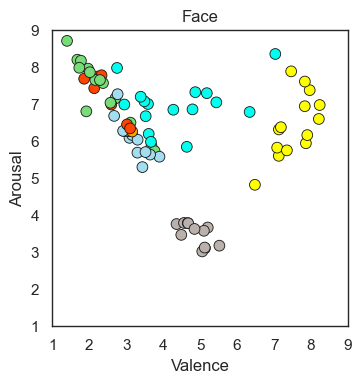

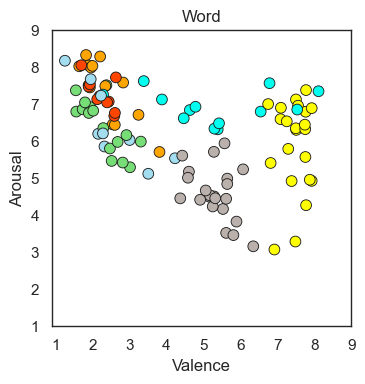

In [ ]:
for i, modality, df in [(1, 'face', face_beh), (2, 'word', word_beh)]:   
    plot_valence_arousal_scatter(df, modality, category_colors,max_category_to_full, f'{modality.capitalize()}', fontsize=12, figsize=(6, 4), if_legend=False,
                                border_width=1,
                                save_svg=True,
                                save=f'./outputs/vector_plots/valence_arousal_scatter_{modality}.svg'
                                )

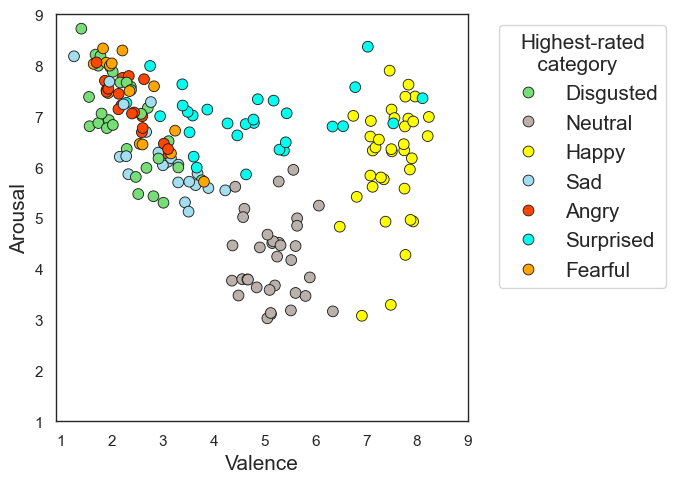

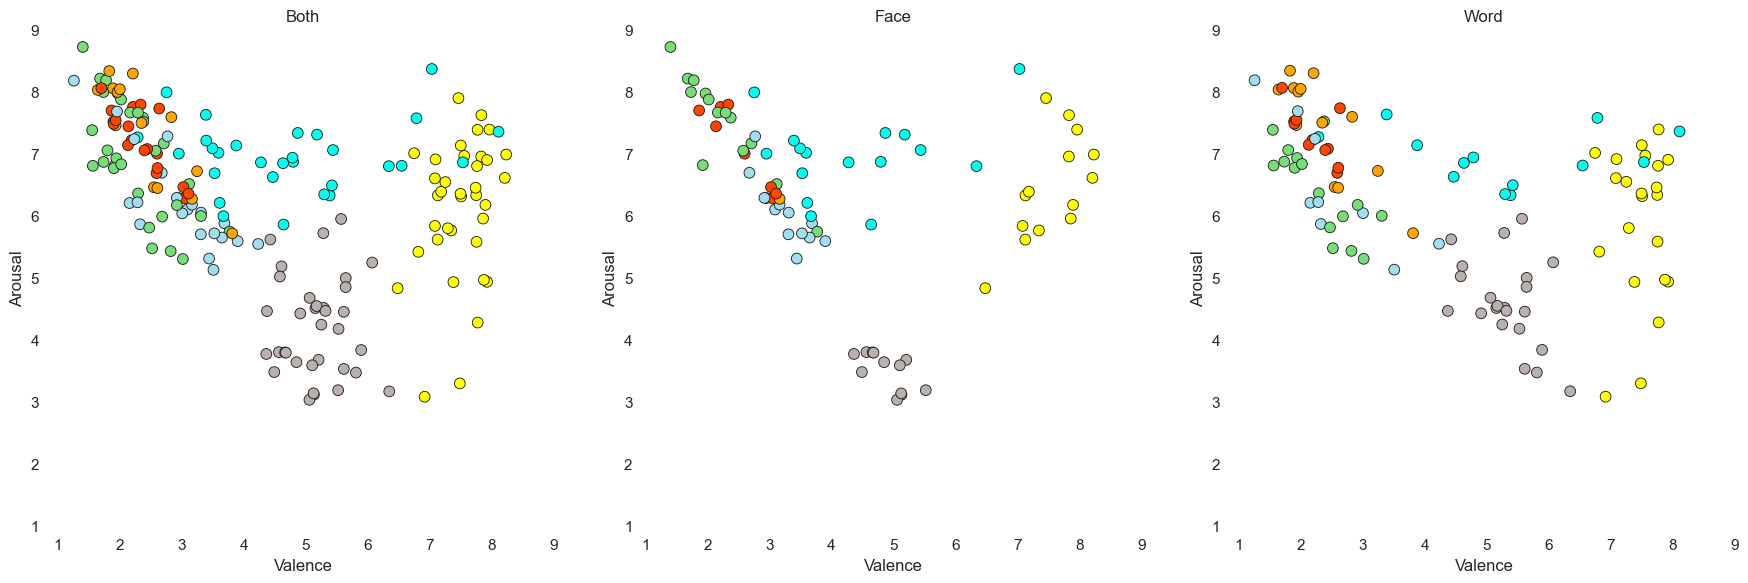

In [19]:
plot_valence_arousal_scatter(both_beh, 'both', category_colors,max_category_to_full, '', fontsize=15, figsize=(7, 5), if_legend=True,
                            save_svg=True,border_width=1,
                             save='./outputs/vector_plots/valence_arousal_scatter_bothModalities.svg')

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for i, modality, df in [(0, 'both', both_beh), (1, 'face', face_beh), (2, 'word', word_beh)]:   
    plot_valence_arousal_scatter(df, modality, category_colors,max_category_to_full, f'{modality.capitalize()}', fontsize=12, figsize=(6, 4), ax=axs[i], if_legend=False)


D = 1: Stress: 296.30936947647086, Kruskal Stress: 0.4318645694677644
D = 2: Stress: 39.20081158470482, Kruskal Stress: 0.15708054979425934
D = 3: Stress: 24.89262710509092, Kruskal Stress: 0.12517288157566245
D = 4: Stress: 23.07397409826374, Kruskal Stress: 0.12051360662847097
D = 5: Stress: 23.03575124485444, Kruskal Stress: 0.12041374773252744
Observed Procrustes distance = 0.201
Mean shuffled distance = 0.992 ± 0.006
p = 0.0000


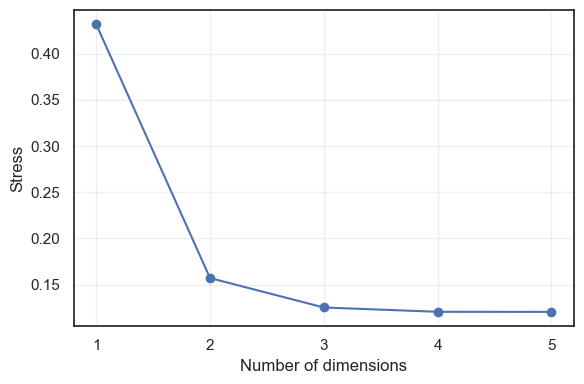

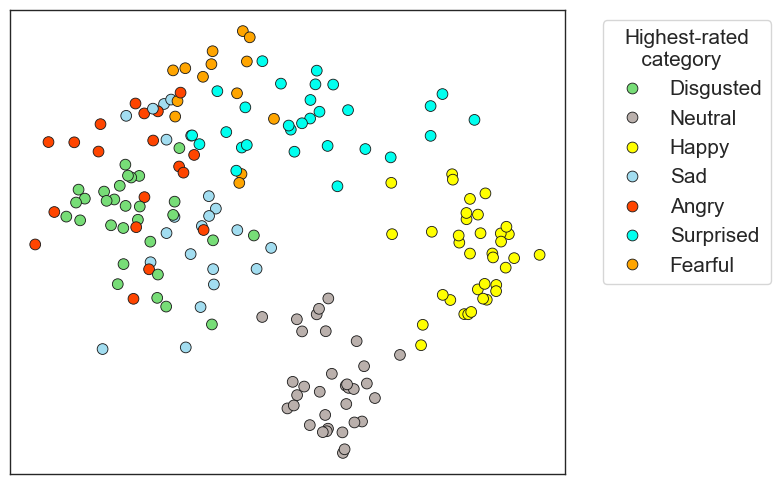

In [ ]:
plot_mds_stimuli(both_beh, 'both', categories,category_colors,max_category_to_full, '', fontsize=15, figsize=(8, 5), if_legend=True,
                             save_svg=True,
                             #save='./outputs/vector_plots/MDS_aligned_seed1_scatter_bothModalities_wborders.svg',
                             random_state=1, align_to_va=True, report_procrustes=True, report_stress=True, report_stress_save='./outputs/vector_plots/scree_plot.svg')

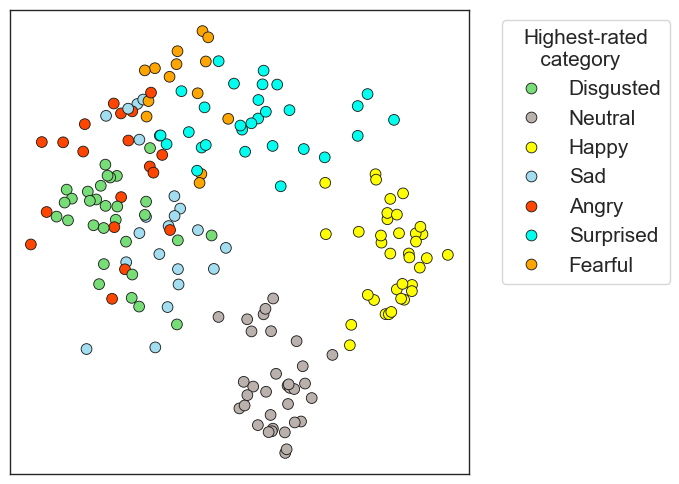

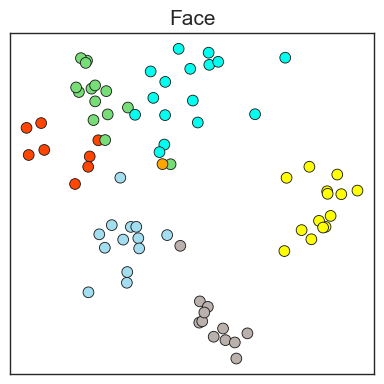

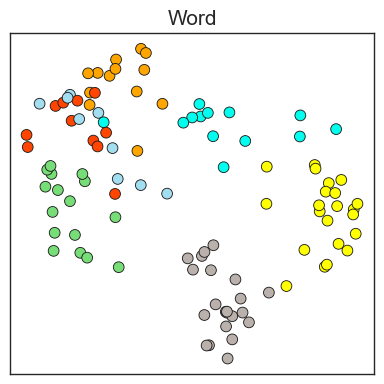

In [37]:
plot_mds_stimuli(both_beh, 'both', categories,category_colors,max_category_to_full, '', fontsize=15, figsize=(7, 5), if_legend=True,
                             save_svg=True,
                             save='./outputs/vector_plots/MDS_aligned_seed1_scatter_bothModalities.svg',
                             random_state=1, align_to_va=True)

for i, modality, df in [(1, 'face', face_beh), (2, 'word', word_beh)]:
    plot_mds_stimuli(df, modality, categories, category_colors,max_category_to_full, f'{modality.capitalize()}', align_to_va=True,fontsize=15, figsize=(4, 4),ax=None, if_legend=False, random_state=1,
                    save_svg=True,
                    save=f'./outputs/vector_plots/MDS_aligned_seed1_scatter_{modality}.svg')

##### Individual ones

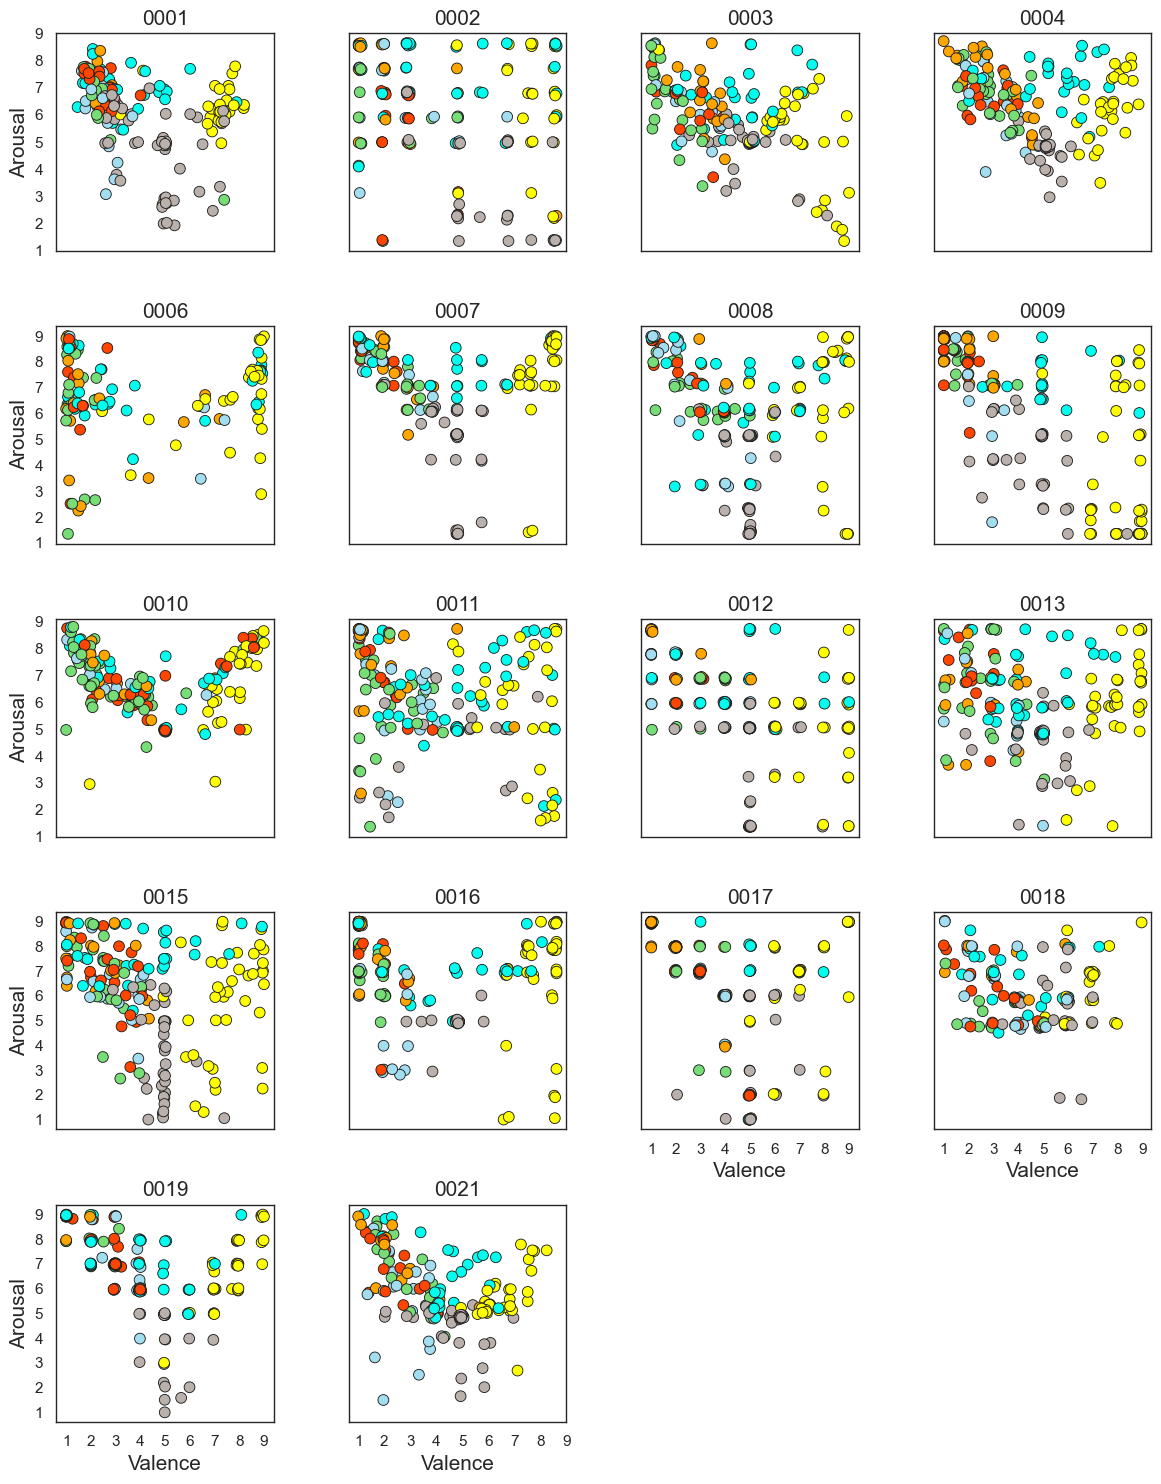

In [29]:
subjects = ['0001','0002','0003','0004','0006','0007','0008','0009','0010', '0011', '0012', '0013', '0015', '0016', '0017', '0018', '0019', '0021']
max_category_to_full = {'HAP': 'Happy', 'AFR': 'Fearful', 'SAD': 'Sad', 'SUR': 'Surprised', 'ANG': 'Angry', 'NEU': 'Neutral', 'DIS': 'Disgusted'}
categories = ['hap', 'fear', 'sad', 'surprise', 'anger','neutral','disgust']
category_colors = {
    'Happy': '#FFFF00',#'#f8a84d',
    'Fearful':  'orange',
    'Sad': '#A2DDF0',#'#9c755f',
    'Surprised': '#00FFEF',#'#59a14f',
    'Angry': 'orangered',#'#e15759',
    'Neutral': '#bab0ac',
    'Disgusted': '#77DD77'
}
num_cols = 4
num_rows = math.ceil(len(subjects)/num_cols)
fig, axs = plt.subplots(num_rows, num_cols, figsize=(3*num_cols, 3*num_rows))#, constrained_layout=True)
fig.subplots_adjust(
    left=0.02, right=0.995,
    top=0.995, bottom=0.02,
    wspace=0.05, hspace=0.05
)

for i,  sub in enumerate(subjects):
    face_beh = pd.read_csv(f'./data/beh/behTables_singleStim/sub{sub}/sub{sub}_table_face_singleStim.csv')
    word_beh = pd.read_csv(f'./data/beh/behTables_singleStim/sub{sub}/sub{sub}_table_word_singleStim.csv')
    categories = ['hap', 'fear', 'sad', 'surprise', 'anger','neutral','disgust']
    for cat in categories+['v', 'a']:
        face_beh[f'both_{cat}_slider.response_mean'] = face_beh[f'face_{cat}_slider.response_mean']
        word_beh[f'both_{cat}_slider.response_mean'] = word_beh[f'word_{cat}_slider.response_mean']


    both_beh = pd.concat([face_beh, word_beh], ignore_index=True)
    #drop rows with nan values in 'both_{cat}_slider.response_mean'
    for cat in categories:
        both_beh = both_beh[~np.isnan(both_beh[f'both_{cat}_slider.response_mean'] )]
    max_category_labels = face_beh['max_category'].unique()
    #determine locaiton of the plot given that there are 3 columns and len(subjects) rows
    col_idx = i % num_cols
    row_idx = i // num_cols
    ax = axs[row_idx, col_idx]

    if (row_idx == num_rows - 1) or (row_idx == num_rows - 2 and col_idx >= 2):
        remove_x_labelticks = False
    else:
        remove_x_labelticks = True
    if col_idx != 0:
        remove_y_labelticks = True
    else:
        remove_y_labelticks = False

    plot_valence_arousal_scatter(both_beh, 'both', category_colors,max_category_to_full, sub, fontsize=15, figsize=(4, 4), ax=ax, if_legend=False,border_width=1, remove_x_labelticks=remove_x_labelticks, remove_y_labelticks=remove_y_labelticks, box_auto=True)

for j in range(len(subjects), num_rows * num_cols):
    axs.ravel()[j].axis("off")

for ax in axs.ravel():
    #ax.set_aspect('equal', adjustable='datalim')
    ax.set_box_aspect(1)
#save the figure
fig.savefig('./outputs/vector_plots/valence_arousal_scatter_bothModalities_individual.svg', format='svg', bbox_inches='tight')

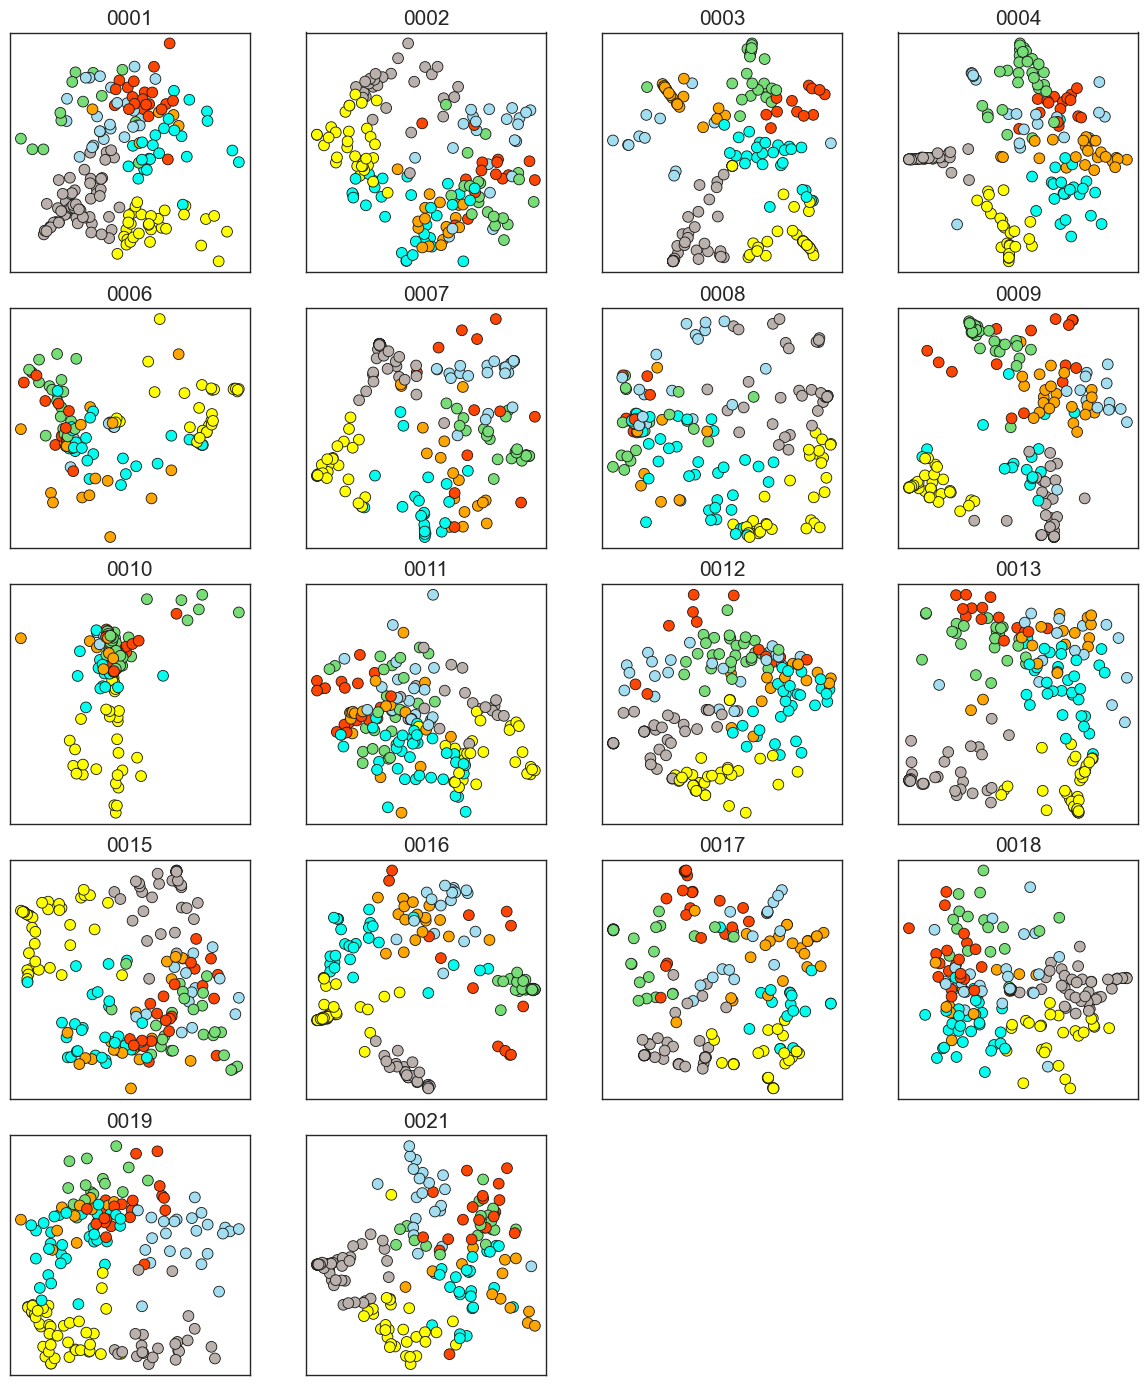

In [30]:
subjects = ['0001','0002','0003','0004','0006','0007','0008','0009','0010','0011','0012','0013','0015','0016','0017','0018','0019','0021']

num_cols = 4
num_rows = math.ceil(len(subjects) / num_cols)

fig, axs = plt.subplots(num_rows, num_cols,figsize=(3*num_cols, 3*num_rows))

for i, sub in enumerate(subjects):
    face_beh = pd.read_csv(f'./data/beh/behTables_singleStim/sub{sub}/sub{sub}_table_face_singleStim.csv')
    word_beh = pd.read_csv(f'./data/beh/behTables_singleStim/sub{sub}/sub{sub}_table_word_singleStim.csv')

    categories = ['hap', 'fear', 'sad', 'surprise', 'anger','neutral','disgust']
    for cat in categories+['v', 'a']:
        face_beh[f'both_{cat}_slider.response_mean'] = face_beh[f'face_{cat}_slider.response_mean']
        word_beh[f'both_{cat}_slider.response_mean'] = word_beh[f'word_{cat}_slider.response_mean']

    both_beh = pd.concat([face_beh, word_beh], ignore_index=True)
    for cat in categories:
        both_beh = both_beh[~np.isnan(both_beh[f'both_{cat}_slider.response_mean'])]

    col_idx = i % num_cols
    row_idx = i // num_cols
    ax = axs[row_idx, col_idx]

    plot_mds_stimuli(both_beh, 'both', categories,category_colors, max_category_to_full,sub, fontsize=15, figsize=(4, 4),ax=ax, if_legend=False)


# hide empty panels
for j in range(len(subjects), num_rows * num_cols):
    axs.ravel()[j].axis("off")

# make square & compact
for ax in axs.ravel():
    ax.set_box_aspect(1)

fig.subplots_adjust(
    left=0.02, right=0.995,
    top=0.995, bottom=0.1,
    wspace=0.05, hspace=0.15   # <-- increase this
)


fig.savefig('./outputs/vector_plots/MDS_aligned_seed1_scatter_bothModalities_individual.svg',format='svg', bbox_inches='tight')


### In-out-scanner consistency

In [11]:
def get_final_comparison_type(sub_id, run_id, modality):
    if modality == 'word':
        if int(sub_id)%4 == 1 or int(sub_id)%4 == 2:
            final_comparison_type = 'PLEASANTNESS' if run_id == 1 else 'ACTIVATION'
        else:
            final_comparison_type = 'ACTIVATION' if run_id == 1 else 'PLEASANTNESS'
    elif modality == 'face':
        final_comparison_type = 'PLEASANTNESS'
    return final_comparison_type

def load_inscan_beh(beh_dir, sub_id, run_id, modality):
    inscan_beh = pd.read_csv(glob.glob(f'{beh_dir}/sub-{sub_id}/*task-{modality}_run-{run_id}*.csv')[0]) 
    last_idx = inscan_beh.index[-1]
    inscan_beh.loc[last_idx, 'comparison_rating'] = inscan_beh.loc[last_idx, 'comparison_rating_final']
    inscan_beh.loc[last_idx, 'comparison_forPreviousTrial'] = get_final_comparison_type(sub_id, run_id, modality)
    return inscan_beh

def extract_inscan_beh(inscan_beh, stim_columns_names, run_id):
    stim_columns = inscan_beh[stim_columns_names].iloc[1:-1,:].reset_index(drop=True)
    rating_column = inscan_beh['comparison_rating'][2:].reset_index(drop=True)
    comparison_type_column = inscan_beh['comparison_forPreviousTrial'][2:].reset_index(drop=True)
    run_id_column = pd.Series([run_id] * len(rating_column), index=rating_column.index)
    return pd.concat([stim_columns, rating_column, comparison_type_column, run_id_column], axis=1, ignore_index=True)

def add_outscan_beh(behTables_dir, inscan_beh, sub_id, modality, stim_info_to_match, source, categories):
    try:
        if source == 'subspec':
            outscan_beh = pd.read_csv(f'{behTables_dir}/sub{sub_id}/sub{sub_id}_table_{modality}.csv')
        elif source == 'subavg':
            outscan_beh = pd.read_csv(f'{behTables_dir}/subAvg_table_{modality}.csv')
    except:
        print(f"Warning: No {source} table found for sub{sub_id}")
        inscan_beh[f'{source}_valence_change'] = np.nan
        inscan_beh[f'{source}_arousal_change'] = np.nan
        inscan_beh[f'{source}_category_distance'] = np.nan
        inscan_beh[f'{source}_maxcategory_distance'] = np.nan
        inscan_beh[f'{source}_euclidean_distance'] = np.nan
        inscan_beh[f'{source}_theta'] = np.nan
        return inscan_beh
    for index, row in inscan_beh.iterrows():
        mask = pd.Series([True] * len(outscan_beh), index=outscan_beh.index)
        for out_col, in_col in stim_info_to_match[modality]:
            mask &= outscan_beh[out_col] == row[in_col]
        outscan_row = outscan_beh[mask]
        if not outscan_row.empty:
            inscan_beh.loc[index, f'{source}_valence_change'] = (outscan_row['end_valence'].values[0] - outscan_row['start_valence'].values[0])
            inscan_beh.loc[index, f'{source}_arousal_change'] = (outscan_row['end_arousal'].values[0] - outscan_row['start_arousal'].values[0])
            inscan_beh.loc[index, f'{source}_theta'] = outscan_row['theta'].values[0]
            inscan_beh.loc[index, f'{source}_euclidean_distance'] = np.sqrt(inscan_beh.loc[index, f'{source}_valence_change']**2 + inscan_beh.loc[index, f'{source}_arousal_change']**2)
            inscan_beh.loc[index, f'{source}_category_distance'] = cosine(outscan_row[[f'start_{cat}' for cat in categories]].values.flatten(), outscan_row[[f'end_{cat}' for cat in categories]].values.flatten())
            #get distance between the starting and ending's max category (if they share the same max category, then just get rating difference between the starting and ending; if they have different max categories, then get the average distances across the two max categories between the starting and ending
            start_max_name = categories[outscan_row[[f'start_{cat}' for cat in categories]].values.flatten().argmax()]
            end_max_name = categories[outscan_row[[f'end_{cat}' for cat in categories]].values.flatten().argmax()]
            start_max_diff = abs(outscan_row[f'start_{start_max_name}'].values[0] - outscan_row[f'end_{start_max_name}'].values[0])
            end_max_diff = abs(outscan_row[f'start_{end_max_name}'].values[0] - outscan_row[f'end_{end_max_name}'].values[0])
            inscan_beh.loc[index, f'{source}_maxcategory_distance'] = (start_max_diff + end_max_diff) / 2
        else:
            print(f"Warning: No match for inscan row {index} with "
              f"start: {row['start_category']}, end: {row['end_category']}, group: {row['group']}")
    return inscan_beh

def get_inoutscan_consistency(inoutscan_beh, source, small_change_threshold=1, exclude_small_change=False):
    for index, row in inoutscan_beh.iterrows():
        if row['comparison_type'] == 'PLEASANTNESS':
            if abs(row[f'{source}_valence_change']) < small_change_threshold:
                inoutscan_beh.loc[index, f'{source}_change'] = 1.0
            elif row[f'{source}_valence_change'] > small_change_threshold:
                inoutscan_beh.loc[index, f'{source}_change'] = 2.0
            elif row[f'{source}_valence_change'] < -small_change_threshold:
                inoutscan_beh.loc[index, f'{source}_change'] = 3.0
            else:
                inoutscan_beh.loc[index, f'{source}_change'] = np.nan
        elif row['comparison_type'] == 'ACTIVATION':
            if abs(row[f'{source}_arousal_change']) < small_change_threshold:
                inoutscan_beh.loc[index, f'{source}_change'] = 1.0
            elif row[f'{source}_arousal_change'] > small_change_threshold:
                inoutscan_beh.loc[index, f'{source}_change'] = 2.0
            elif row[f'{source}_arousal_change'] < -small_change_threshold:
                inoutscan_beh.loc[index, f'{source}_change'] = 3.0
            else:
                inoutscan_beh.loc[index, f'{source}_change'] = np.nan

        if exclude_small_change:
            if row['comparison_type'] == 'PLEASANTNESS':
                if abs(row[f'{source}_valence_change']) < small_change_threshold:
                    inoutscan_beh.loc[index, f'{source}_consistency'] = np.nan # Set to NaN if change is small and excluded
                elif row['inscan_rating'] == inoutscan_beh.loc[index, f'{source}_change']:
                    inoutscan_beh.loc[index, f'{source}_consistency'] = 'consistent'
                else:
                    inoutscan_beh.loc[index, f'{source}_consistency'] = 'inconsistent'
            elif row['comparison_type'] == 'ACTIVATION':
                if abs(row[f'{source}_arousal_change']) < small_change_threshold:
                    inoutscan_beh.loc[index, f'{source}_consistency'] = np.nan # Set to NaN if change is small and excluded
                elif row['inscan_rating'] == inoutscan_beh.loc[index, f'{source}_change']:
                    inoutscan_beh.loc[index, f'{source}_consistency'] = 'consistent'
                else:
                    inoutscan_beh.loc[index, f'{source}_consistency'] = 'inconsistent'
        else: # if exclude_small_change is False
            if row['inscan_rating'] == inoutscan_beh.loc[index, f'{source}_change']:
                inoutscan_beh.loc[index, f'{source}_consistency'] = 'consistent'
            elif pd.isna(inoutscan_beh.loc[index, f'{source}_change']):
                inoutscan_beh.loc[index, f'{source}_consistency'] = np.nan
            else:
                inoutscan_beh.loc[index, f'{source}_consistency'] = 'inconsistent'

    return inoutscan_beh

def compute_consistency_breakdown(
    sub_list, modality_list, source_list, small_change_thresholds,
    beh_dir, behTables_dir, run_list, stim_columns_names,
    stim_info_to_match_subspec_subavg,
    change_ranges=[(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)], if_change_range_quantile=False,
    change_ranges_category_distance=None,
    change_ranges_maxcategory_distance=None,
    change_ranges_euclidean_distance=None,
    categories=None
):
    consistency_data = []
    breakdown_data = []
    breakdown_data_category_distance = []
    breakdown_data_maxcategory_distance = []
    breakdown_data_euclidean_distance = []
    inoutscan_beh_allsubs = pd.DataFrame()
    for sub_id in sub_list:
        for modality in modality_list:
            for source in source_list:
                inscan_beh = pd.concat([extract_inscan_beh(load_inscan_beh(beh_dir, sub_id, run_id, modality),stim_columns_names[modality],run_id)
                    for run_id in run_list
                ], ignore_index=True).reset_index(drop=True)

                inscan_beh = inscan_beh.rename(columns={i: stim_columns_names[modality][i] for i in range(len(stim_columns_names[modality]))}
                        ).rename(columns={len(stim_columns_names[modality]): 'inscan_rating',len(stim_columns_names[modality]) + 1: 'comparison_type',len(stim_columns_names[modality]) + 2: 'run'})


                inoutscan_beh = add_outscan_beh(behTables_dir, inscan_beh, sub_id, modality, stim_info_to_match_subspec_subavg, source, categories) 


                for thresh in small_change_thresholds:
                    inoutscan_beh = get_inoutscan_consistency(inoutscan_beh, source,small_change_threshold=thresh,exclude_small_change=False)
                    inoutscan_beh['sub_id'] = sub_id

                    inoutscan_beh_to_concat = inoutscan_beh.copy()
                    inoutscan_beh_to_concat['source'] = source
                    inoutscan_beh_to_concat['modality'] = modality
                    inoutscan_beh_to_concat['threshold'] = thresh
                    inoutscan_beh_to_concat = inoutscan_beh_to_concat.rename(columns={f'{source}_valence_change': 'outscan_valence_change',f'{source}_arousal_change': 'outscan_arousal_change',
                                                                                      f'{source}_theta': 'outscan_theta',
                                                                                      f'{source}_consistency': 'outscan_consistency', f'{source}_change': 'outscan_change',
                                                                                      f'{source}_category_distance': 'outscan_category_distance', f'{source}_maxcategory_distance': 'outscan_maxcategory_distance',
                                                                                      f'{source}_euclidean_distance': 'outscan_euclidean_distance'})
                    inoutscan_beh_allsubs = pd.concat([inoutscan_beh_allsubs, inoutscan_beh_to_concat])

                    for run_id in run_list:
                        run_data = inoutscan_beh[inoutscan_beh['run'] == run_id]    
                        # Consistency counts
                        counts = run_data[f"{source}_consistency"].value_counts()
                        for label in ['consistent', 'inconsistent']:
                            consistency_data.append({'source': source,'consistency': label,'count': counts.get(label, 0),'subject': sub_id,'modality': modality,'threshold': thresh,'run': run_id})

                        # Breakdown by outscan change range
                        for comp_type, col_name in [(['PLEASANTNESS'], f'{source}_valence_change'),(['ACTIVATION'], f'{source}_arousal_change')]:
                            subset = run_data[run_data['comparison_type'].isin(comp_type)]
                            if if_change_range_quantile:
                                #get the quantile of the change
                                change_quantile = np.quantile(subset[col_name].abs(), [0, 0.25, 0.5, 0.75, 1])
                                change_ranges = list(zip(change_quantile[:-1], change_quantile[1:]))
                            if not subset.empty:
                                for i, (lower, upper) in enumerate(change_ranges):
                                    range_subset = subset[(subset[col_name].abs() >= lower) & (subset[col_name].abs() < upper)]
                                    range_counts = range_subset[f"{source}_consistency"].value_counts()
                                    for label in ['consistent', 'inconsistent']:
                                        change_range_label = f'{lower}-{upper}' if not if_change_range_quantile else f'Q{i+1}'
                                        breakdown_data.append({'source': source,'consistency': label,'outscan_change_range': change_range_label,'count': range_counts.get(label, 0),'comparison_type': comp_type[0],'subject': sub_id,'modality': modality,'threshold': thresh,'run': run_id})

                        for dist_type, change_ranges_cate, breakdown_list in [('category_distance', change_ranges_category_distance, breakdown_data_category_distance), ('maxcategory_distance', change_ranges_maxcategory_distance, breakdown_data_maxcategory_distance), ('euclidean_distance', change_ranges_euclidean_distance, breakdown_data_euclidean_distance)]:
                            if if_change_range_quantile:
                                change_quantile = np.quantile(run_data[f'{source}_{dist_type}'], [0, 0.25, 0.5, 0.75, 1])
                                change_ranges_cate = list(zip(change_quantile[:-1], change_quantile[1:]))
                                change_ranges_maxcategory_distance = change_ranges_cate
                                change_ranges_euclidean_distance = np.quantile(run_data[f'{source}_euclidean_distance'], [0, 0.25, 0.5, 0.75, 1])
                            for i, (lower, upper) in enumerate(change_ranges_cate):
                                range_subset = run_data[(run_data[f'{source}_{dist_type}'] >= lower) & (run_data[f'{source}_{dist_type}'] < upper)]
                                range_counts = range_subset[f"{source}_consistency"].value_counts()
                                for label in ['consistent', 'inconsistent']:
                                    change_range_label = f'{lower}-{upper}' if not if_change_range_quantile else f'Q{i+1}'
                                    breakdown_list.append({'source': source,'consistency': label,'outscan_change_range': change_range_label,'count': range_counts.get(label, 0),'subject': sub_id,'modality': modality,'threshold': thresh,'run': run_id})
                                    
    return pd.DataFrame(consistency_data), pd.DataFrame(breakdown_data), pd.DataFrame(breakdown_data_category_distance), pd.DataFrame(breakdown_data_maxcategory_distance), pd.DataFrame(breakdown_data_euclidean_distance), inoutscan_beh_allsubs 

def plot_overall_consistency(df_consistency):
    sns.set(style='whitegrid')
    for modality in df_consistency['modality'].unique():
        for threshold in df_consistency['threshold'].unique():
            subset = df_consistency[
                (df_consistency['modality'] == modality) &
                (df_consistency['threshold'] == threshold)]
            g = sns.catplot(data=subset,kind='bar',x='source', y='count',hue='consistency',col='subject',col_wrap=5,height=4,palette='Set2')
            g.fig.suptitle(f'Overall Consistency ({modality}, Threshold={threshold})', y=1.05)
            plt.tight_layout()
            plt.show()


def plot_breakdown_by_range(df_breakdown, change_range_order=None):
    if change_range_order is None:
        change_range_order = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8']

    for comp_type in df_breakdown['comparison_type'].unique():
        for modality in df_breakdown['modality'].unique():
            for threshold in df_breakdown['threshold'].unique():
                subset = df_breakdown[
                    (df_breakdown['comparison_type'] == comp_type) &
                    (df_breakdown['modality'] == modality) &
                    (df_breakdown['threshold'] == threshold)]
                g = sns.catplot(data=subset,kind="bar",x="OutscanChangeRange",y="Count",hue="Consistency",row="Sub",col="Source",height=2.5,aspect=1.2,palette="Set2",dodge=True,order=change_range_order)
                g.set_axis_labels("Absolute Difference", "Count")
                g.fig.subplots_adjust(top=0.9)
                g.fig.suptitle(f"{comp_type}: {modality} Threshold={threshold}")
                plt.show()

In [12]:
beh_dir = './data/beh'
behTables_dir = './data/beh/behTables'
sub_list = ['0001', '0002', '0003', '0004','0007','0008','0009','0010','0011','0012','0013','0014','0015','0016','0017','0018','0019','0021']
modality_list = ['face', 'word']
run_list = ['01', '02']
categories = ['hap', 'fear', 'sad', 'surprise', 'anger', 'neutral', 'disgust']
small_change_thresholds = [1]
stim_columns_names = {'face':['morph', 'start_category', 'end_category', 'group'], 
                      'word':['start_word', 'end_word', 'start_category', 'end_category', 'group']}
stim_info_to_match_subspec_subavg = {'face':[('ori_start_category', 'start_category'), ('ori_end_category', 'end_category'), ('group', 'group')], 
                           'word':[('start_stimulus', 'start_word'), ('end_stimulus', 'end_word'), ('group', 'group')]}

consistency_df, breakdown_df, breakdown_df_category_distance, breakdown_df_maxcategory_distance, breakdown_df_euclidean_distance, inoutscan_beh_allsubs= compute_consistency_breakdown(
    sub_list=sub_list,
    modality_list=['face', 'word'],
    source_list=['subavg', 'subspec'],
    small_change_thresholds=[1.0],
    beh_dir=beh_dir,
    behTables_dir=behTables_dir,
    run_list=run_list,
    stim_columns_names=stim_columns_names,
    stim_info_to_match_subspec_subavg=stim_info_to_match_subspec_subavg,
    change_ranges=None,#[(0, 1), (1, 2), (2, 4), (4, 8)],
    change_ranges_category_distance=None,#[(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8)],
    change_ranges_maxcategory_distance=None,#[(0, 2), (2, 4), (4, 6), (6, 8)],
    change_ranges_euclidean_distance=None,#[(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)],
    if_change_range_quantile=True,
    categories=categories
)

In [10]:
#get the outscan_rating_change by getting abs(outscan_{vora}_change) depending on the comparison_type
# Map from comparison_type to the correct column suffix for change
type_to_suffix = {'PLEASANTNESS': 'valence', 'ACTIVATION': 'arousal'}
def get_outscan_rating_change(row):
    comp_type = row['comparison_type']
    if comp_type in type_to_suffix:
        suffix = type_to_suffix[comp_type]
        return abs(row[f'outscan_{suffix}_change'])
    else:
        return np.nan

inoutscan_beh_allsubs['outscan_rating_change'] = inoutscan_beh_allsubs.apply(get_outscan_rating_change, axis=1)

In [16]:
def get_outscan_rating_change_signed(row):
    comp_type = row['comparison_type']
    if comp_type in type_to_suffix:
        suffix = type_to_suffix[comp_type]
        return row[f'outscan_{suffix}_change']
    else:
        return np.nan

inoutscan_beh_allsubs['outscan_rating_change_signed'] = inoutscan_beh_allsubs.apply(get_outscan_rating_change_signed, axis=1)

In [ ]:
#change consistent to 1 and inconsistent to 0 in outscan_consistency column
#inoutscan_beh_allsubs['outscan_consistency'] = inoutscan_beh_allsubs['outscan_consistency'].map({'consistent': 1, 'inconsistent': 0})
#inoutscan_beh_allsubs.to_csv("./outputs/inoutscan_beh_allsubs_wMaxCategoryDistance.csv", index=False)

In [20]:
def assign_correct_direction(df):
    df = df.copy()
    df["signed_change"] = np.where(
        df["comparison_type"] == "PLEASANTNESS",
        df["outscan_valence_change"],
        np.where(df["comparison_type"] == "ACTIVATION", df["outscan_arousal_change"], np.nan))
    df["correct_direction"] = np.select(
        [df["outscan_rating_change"] < 1,
            (df["outscan_rating_change"] > 1) & (df["signed_change"] > 0),
            (df["outscan_rating_change"] > 1) & (df["signed_change"] < 0)],
        ["no_change", "increase", "decrease"], default="boundary")
    return df

subavg_beh = assign_correct_direction(inoutscan_beh_allsubs.query('source == "subavg"'))

direction_counts = subavg_beh.groupby(["sub_id", "modality", "correct_direction"]).size().unstack(fill_value=0).reset_index()
for col in ["decrease", "increase", "no_change", "boundary"]:
    if col not in direction_counts.columns:
        direction_counts[col] = 0

direction_counts["analyzed_trials"] = direction_counts[["decrease", "increase", "no_change"]].sum(axis=1)
for col in ["decrease", "increase", "no_change"]:
    direction_counts[f"{col}_proportion"] = direction_counts[col] / direction_counts["analyzed_trials"]
# Pool face & word trials for each participant
both_counts = (direction_counts
    .groupby("sub_id", as_index=False)[["decrease", "increase", "no_change", "boundary"]].sum()
    .assign(modality="both",analyzed_trials=lambda df: df[["decrease", "increase", "no_change"]].sum(axis=1)))
for col in ["decrease", "increase", "no_change"]:
    both_counts[f"{col}_proportion"] = both_counts[col] / both_counts["analyzed_trials"]

direction_counts_all = pd.concat([direction_counts, both_counts], ignore_index=True)

In [31]:
# Get the proportions of the outscan_consistency for each 'ground truth' direction 
class_accuracy = (
    subavg_beh
    .groupby(['sub_id', 'correct_direction', 'source'])['outscan_consistency']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
    .pivot_table(
        index=['sub_id', 'correct_direction', 'source'],
        columns='outscan_consistency',
        values='proportion',
        fill_value=0)
    .reset_index())

#print(class_accuracy.to_string())
class_accuracy_summary = (
    class_accuracy
    .groupby("correct_direction")["consistent"]
    .agg(min="min",max="max",median="median",q1=lambda x: x.quantile(0.25),q3=lambda x: x.quantile(0.75))
    .reset_index())
class_accuracy_summary["IQR"] = (class_accuracy_summary["q3"] - class_accuracy_summary["q1"])
print(class_accuracy_summary.to_string(index=False))

balanced_accuracy = (
    class_accuracy
    .query('correct_direction in ["decrease", "no_change", "increase"]')
    .groupby("sub_id")["consistent"]
    .mean()
    .rename("balanced_accuracy")
    .reset_index()
)
balanced_accuracy_summary = balanced_accuracy["balanced_accuracy"].agg(min="min",max="max",median="median",q1=lambda x: x.quantile(0.25),q3=lambda x: x.quantile(0.75))
balanced_accuracy_summary["IQR"] = (balanced_accuracy_summary["q3"] - balanced_accuracy_summary["q1"])
print(balanced_accuracy_summary)

# Distance by in-scanner choice
mean_outscan_rating_change = (
    inoutscan_beh_allsubs
    .groupby(['sub_id', 'inscan_rating', 'source'])['outscan_rating_change_signed']
    .mean()
    .reset_index()
)
subavg_mean = mean_outscan_rating_change[mean_outscan_rating_change['source'] == 'subavg'].groupby('inscan_rating')['outscan_rating_change_signed'].agg(['mean', 'std'])
print(subavg_mean.to_string())


correct_direction      min      max   median       q1       q3      IQR
         decrease 0.482759 0.912281 0.747881 0.686966 0.807666 0.120700
         increase 0.492754 0.915493 0.767606 0.714436 0.824376 0.109940
        no_change 0.000000 0.585366 0.301282 0.164962 0.352200 0.187239
min       0.516778
max       0.689763
median    0.579222
q1        0.555281
q3        0.625775
IQR       0.070494
Name: balanced_accuracy, dtype: float64
                   mean       std
inscan_rating                    
1.0           -0.056382  0.302713
2.0            1.482370  0.224844
3.0           -1.566662  0.282520


In [ ]:
directions = ["decrease", "increase", "no_change"]

agg_dict = {
    "sub_id": "nunique",
    **{d: ["mean", "std", "min", "max"] for d in directions},
    **{f"{d}_proportion": ["mean", "std"] for d in directions},
    "analyzed_trials": ["mean", "std"],
    "boundary": "sum"
}

direction_summary = direction_counts_all.groupby("modality").agg(agg_dict)
direction_summary.columns = ["_".join(c).rstrip("_") for c in direction_summary.columns]
direction_summary = direction_summary.rename(columns={"sub_id_nunique": "n_subjects"}).reset_index()
direction_summary["modality"] = pd.Categorical(direction_summary["modality"], ["face", "word", "both"], ordered=True)
direction_summary = direction_summary.sort_values("modality").reset_index(drop=True)

report_table = direction_summary[["modality", "n_subjects"]].copy()
for d in directions:
    report_table[d] = direction_summary.apply(
        lambda r: f"{r[f'{d}_mean']:.1f} (SD = {r[f'{d}_std']:.1f}); "
                  f"{100 * r[f'{d}_proportion_mean']:.1f}%",
        axis=1)

print(direction_summary)
print(report_table.to_string(index=False))

  modality  n_subjects  decrease_mean  decrease_std  decrease_min  \
0     face          18      29.444444      4.579009            22   
1     word          18      31.611111      3.220137            27   
2     both          18      61.055556      5.588562            54   

   decrease_max  increase_mean  increase_std  increase_min  increase_max  ...  \
0            39      29.722222      4.675412            21            37  ...   
1            38      39.611111      2.789453            35            45  ...   
2            74      69.333333      5.562479            56            78  ...   

   no_change_max  decrease_proportion_mean  decrease_proportion_std  \
0             28                  0.350529                 0.054512   
1             58                  0.254928                 0.025969   
2             85                  0.293536                 0.026868   

   increase_proportion_mean  increase_proportion_std  \
0                  0.353836                 0.055660   
1

#### judged dimension distance

subavg
         group      mean  ci_lower  ci_upper         d   p_val
0  Face - Word  0.054297  0.022976  0.087942  0.768713  0.0029
range of prop_consistent
0.5096153846153846 0.6634615384615384
mean and std of prop_consistent
0.5734508547008547 0.04628462205041091
Median: 0.5697115384615384
IQR: 0.07211538461538469
Q1 (25th percentile): 0.5348557692307692
Q3 (75th percentile): 0.6069711538461539
subspec
         group      mean  ci_lower  ci_upper         d     p_val
0  Face - Word  0.037639  0.001024  0.079321  0.458318  0.037096
range of prop_consistent
0.4368932038834951 0.6875
mean and std of prop_consistent
0.5703771054428655 0.054029520491890956
Median: 0.5756097560975609
IQR: 0.033653846153846145
Q1 (25th percentile): 0.5625
Q3 (75th percentile): 0.5961538461538461
consistency  consistent  inconsistent  prop_consistent
subject                                               
0001                102           104         0.495146
0010                 90           116         0.43

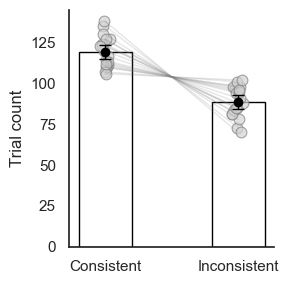

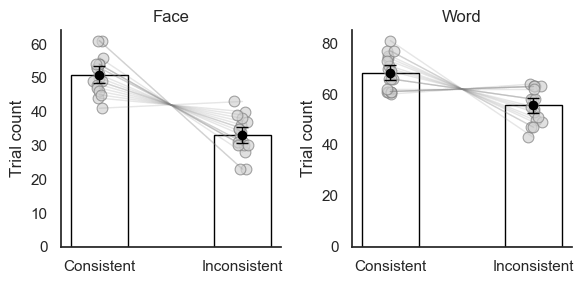

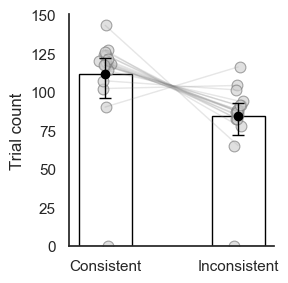

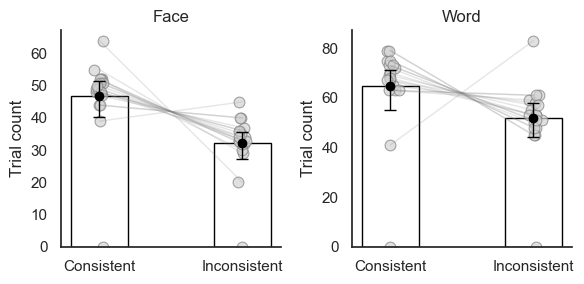

In [42]:
sources = ['subavg', 'subspec']
for source in sources:
        print(source)
        consistency_to_plot = consistency_df.groupby(['source','modality','threshold','subject','consistency']).agg({'count': 'sum'}).reset_index()
        consistency_to_plot1 = consistency_to_plot[consistency_to_plot['source'] == source].groupby(['threshold','subject','consistency']).agg({'count': 'sum'}).reset_index()
        consistency_to_plot2 = consistency_to_plot[(consistency_to_plot['source'] == source) & (consistency_to_plot['modality'] == 'face')] 
        consistency_to_plot3 = consistency_to_plot[(consistency_to_plot['source'] == source) & (consistency_to_plot['modality'] == 'word')] 
        consistency_to_plot_all = {'Both':consistency_to_plot1, 'Face':consistency_to_plot2, 'Word':consistency_to_plot3}
        stats_df = bootstrap_ci(consistency_to_plot_all['Both'], target_col='count', group_vars=['consistency','threshold'])
        plot_subjectConnected_performance_scatter_wbox(consistency_to_plot_all['Both'],'consistency','count','subject',stats_df,
                condition_order=['consistent','inconsistent'], condition_labels=['Consistent','Inconsistent'],
                fill_colors=['lightgray']*2,edge_colors=['gray']*2,connect_subjects=True,line_alpha=0.1,
                plot_box=False, box_edgecolor='lightgray',box_fillcolors=None,
                plot_bar=True,bar_width=0.5,bar_gap=0.2,errorbar_color='black',
                plot_scatter=True,title='',
                figsize=(3,3), ylabel='Trial count',legend=False,
                xlabel='', yrange=None, dotted_yline=None, solid_yline=None, jitter=0.02)#, 
        # save='./outputs/consistency_trial_counts_bothModalities.jpg')

        dfs = {k: (v.pivot(index='subject', columns='consistency', values='count').assign(ratio=lambda d: d['consistent'] / (d['consistent'] + d['inconsistent'])))
                for k, v in consistency_to_plot_all.items()}
        consistency_to_plot_diff = (dfs['Face'].assign(diff=dfs['Face']['ratio'] - dfs['Word']['ratio'],group='Face - Word').reset_index(drop=True))

        print(pd.merge(bootstrap_ci(consistency_to_plot_diff, target_col='diff', group_vars=['group']),
              sign_flip_permutation(consistency_to_plot_diff, target_col='diff', group_vars=['group']),
              on=['group'], how='left').drop(columns=['test_stat']).to_string(max_rows=None, max_cols=None))
        

        fig, axs = plt.subplots(1, 2, figsize=(6, 3))
        for i, modality in enumerate(['Face','Word']):
                stats_df = bootstrap_ci(consistency_to_plot_all[modality], target_col='count', group_vars=['consistency','threshold'])
                plot_subjectConnected_performance_scatter_wbox(consistency_to_plot_all[modality],'consistency','count','subject',stats_df,
                        condition_order=['consistent','inconsistent'], condition_labels=['Consistent','Inconsistent'],
                        fill_colors=['lightgray']*2,edge_colors=['gray']*2,connect_subjects=True,line_alpha=0.1,
                        plot_box=False, box_edgecolor='lightgray',box_fillcolors=None,
                        plot_bar=True,bar_width=0.5,bar_gap=0.2,#errorbar_color='black',
                        plot_scatter=True,title=modality,
                        figsize=(3,3), ylabel='Trial count',legend=False,     
                        xlabel='', yrange=None, dotted_yline=None, solid_yline=None, jitter=0.02, ax=axs[i])#,
                        #save='./outputs/consistency_trial_counts_face_word.jpg')

        df_pivot = consistency_to_plot_all['Both'].pivot(index="subject", columns="consistency", values="count")
        df_pivot["prop_consistent"] = df_pivot["consistent"] / (df_pivot["consistent"] + df_pivot["inconsistent"])
        print('range of prop_consistent')
        print(df_pivot["prop_consistent"].min(), df_pivot["prop_consistent"].max())
        print('mean and std of prop_consistent')
        print(df_pivot["prop_consistent"].mean(), df_pivot["prop_consistent"].std())
        print("Median:", df_pivot["prop_consistent"].median())
        print("IQR:", df_pivot["prop_consistent"].quantile(0.75) - df_pivot["prop_consistent"].quantile(0.25))
        print("Q1 (25th percentile):", df_pivot["prop_consistent"].quantile(0.25))
        print("Q3 (75th percentile):", df_pivot["prop_consistent"].quantile(0.75))
        #if nay df_pivot["prop_consistent"] are smaller than 0.5, print the subject
        if df_pivot["prop_consistent"].min() < 0.5:
                print(df_pivot[df_pivot["prop_consistent"] < 0.5])



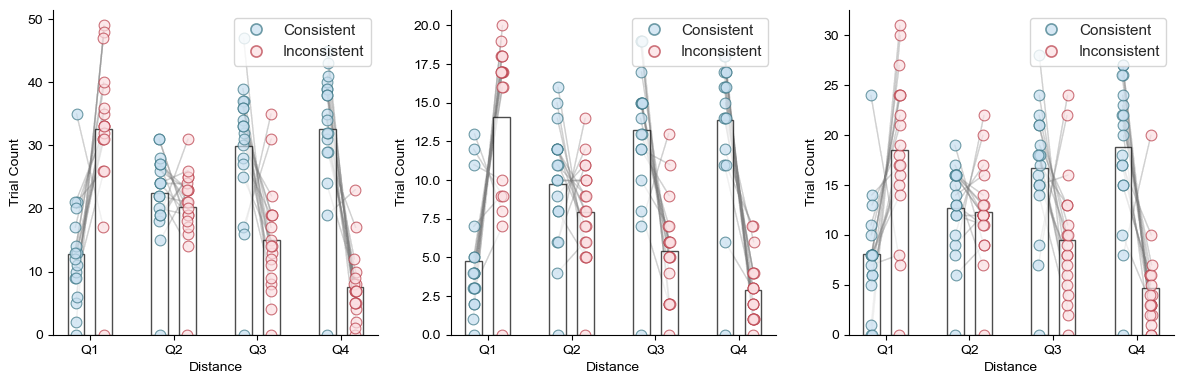

In [6]:
breakdown_to_plot = breakdown_df[breakdown_df['source'] == 'subspec'].groupby(['threshold','subject','modality','consistency','outscan_change_range']).agg({'count': 'sum'}).reset_index()
breakdown_to_plot1 = breakdown_to_plot.groupby(['threshold','subject','consistency','outscan_change_range']).agg({'count': 'sum'}).reset_index()
breakdown_to_plot2 = breakdown_to_plot[breakdown_to_plot['modality'] == 'face'] 
breakdown_to_plot3 = breakdown_to_plot[breakdown_to_plot['modality'] == 'word'] 
breakdown_to_plot_all = {'Both':breakdown_to_plot1, 'Face':breakdown_to_plot2, 'Word':breakdown_to_plot3}
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i, modality in enumerate(['Both','Face','Word']):
    plot_subjectConnected_performance_scatter_wbox_nested(
        breakdown_to_plot_all[modality],'outscan_change_range','consistency','count','subject',stats_df=None,
        outer_order=['Q1', 'Q2', 'Q3', 'Q4'], outer_labels=['Q1', 'Q2', 'Q3', 'Q4'],
        inner_order=['consistent','inconsistent'], inner_labels=['Consistent','Inconsistent'],
        inner_colors=['#C7DFF0','#FBDFE2'], inner_edgecolors=['#377483','#B83945'],
        connect_subjects=True, line_alpha=0.05,
        plot_box=False, box_edgecolor='lightgray', box_fillcolors=None,
        plot_bar=True, errorbar_color='black',bar_fillcolors='white',bar_edgecolors='black',bar_width=0.4,
        plot_scatter=True, plot_ci=False,
        figsize=(8,6), title=None, ylabel='Trial Count',
        xlabel='Distance', legend_loc='upper right', legend_bbox_to_anchor=None,
        jitter=0.02, legend=True, legend_title=None, save=None, ax=axs[i])

In [7]:
consistency_pivot_all = {}
for modality, curr_breakdown_to_plot in breakdown_to_plot_all.items():
    #pivot to get consistent - inconsistent counts based on consistency column per subject and outscan change range
    consistency_pivot = (curr_breakdown_to_plot.pivot_table(index=['subject', 'outscan_change_range'],columns='consistency',values='count',fill_value=0,aggfunc='sum').reset_index())
    consistency_pivot.columns.name = None
    consistency_pivot['diff'] = consistency_pivot.get('consistent', 0) - consistency_pivot.get('inconsistent', 0)
    consistency_pivot['sum'] = consistency_pivot.get('consistent', 0) + consistency_pivot.get('inconsistent', 0)
    consistency_pivot['diff_ratio'] = consistency_pivot['diff'] / consistency_pivot['sum']
    consistency_pivot['ratio'] = consistency_pivot.get('consistent', 0) / consistency_pivot.get('sum', 0)
    consistency_pivot_all[modality] = consistency_pivot

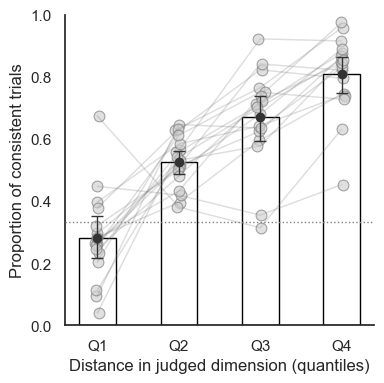

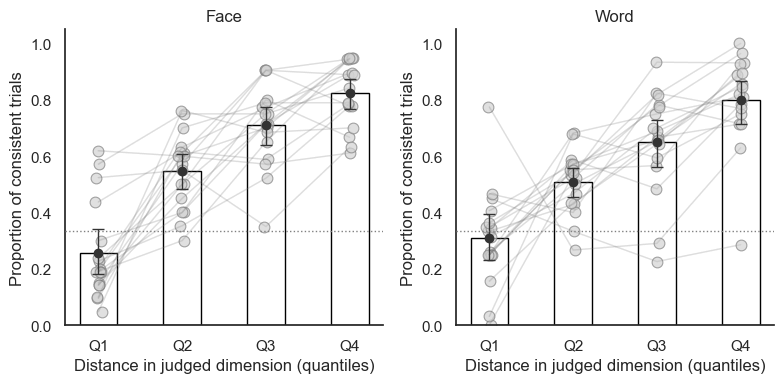

In [ ]:
consistency_pivot_all = {}
for modality, curr_breakdown_to_plot in breakdown_to_plot_all.items():
    #pivot to get consistent - inconsistent counts based on consistency column per subject and outscan change range
    consistency_pivot = (curr_breakdown_to_plot.pivot_table(index=['subject', 'outscan_change_range'],columns='consistency',values='count',fill_value=0,aggfunc='sum').reset_index())
    consistency_pivot.columns.name = None
    consistency_pivot['diff'] = consistency_pivot.get('consistent', 0) - consistency_pivot.get('inconsistent', 0)
    consistency_pivot['sum'] = consistency_pivot.get('consistent', 0) + consistency_pivot.get('inconsistent', 0)
    consistency_pivot['diff_ratio'] = consistency_pivot['diff'] / consistency_pivot['sum']
    consistency_pivot['ratio'] = consistency_pivot.get('consistent', 0) / consistency_pivot.get('sum', 0)
    consistency_pivot_all[modality] = consistency_pivot

stats_df = bootstrap_ci(consistency_pivot_all['Both'], target_col='ratio', group_vars=['outscan_change_range'])
plot_subjectConnected_performance_scatter_wbox(consistency_pivot_all['Both'],'outscan_change_range','ratio','subject',stats_df,
        condition_order=['Q1', 'Q2', 'Q3', 'Q4'], condition_labels=['Q1', 'Q2', 'Q3', 'Q4'],
        fill_colors=['lightgray']*4,edge_colors=['gray']*4,connect_subjects=True,line_alpha=0.07,
        plot_box=False, box_edgecolor='lightgray',box_fillcolors=None,
        plot_bar=True,bar_width=0.5,bar_gap=0.1,
        errorbar_color='#333333',
        plot_scatter=True,#plot_ci=True,
        title='',
        figsize=(4,4), ylabel='Proportion of consistent trials',legend=False,
        xlabel='Distance in judged dimension (quantiles)', yrange=(0, 1), dotted_yline=1/3, solid_yline=None, jitter=0.02, 
        save_svg=True,
        save='./outputs/vector_plots/consistency_trial_ratios_bothModalities_subspec.svg')

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
for i, modality in enumerate(['Face','Word']):
        stats_df = bootstrap_ci(consistency_pivot_all[modality], target_col='ratio', group_vars=['outscan_change_range'])
        plot_subjectConnected_performance_scatter_wbox(consistency_pivot_all[modality],'outscan_change_range','ratio','subject',stats_df,
                condition_order=['Q1', 'Q2', 'Q3', 'Q4'], condition_labels=['Q1', 'Q2', 'Q3', 'Q4'],
                fill_colors=['lightgray']*4,edge_colors=['gray']*4,connect_subjects=True,line_alpha=0.07,
                plot_box=False, box_edgecolor='lightgray',box_fillcolors=None,
                plot_bar=True,bar_width=0.5,bar_gap=0.1,
                errorbar_color='#333333',
                plot_scatter=True,#plot_ci=True,
                title=modality,
                figsize=(4,4), ylabel='Proportion of consistent trials',legend=False,
                xlabel='Distance in judged dimension (quantiles)', yrange=(0, 1.05), dotted_yline=1/3, solid_yline=None, jitter=0.02, ax=axs[i],
                save_svg=True,
                #save='./outputs/vector_plots/consistency_trial_ratios_face_word_subspec.svg'
                )


Comparison type: ACTIVATION
  Range: 0.41 - 0.6082474226804123
  Median: 0.4815541601255887
  IQR: 0.5234663172199573 - 0.436582318025617 = 0.08688399919434031
Comparison type: PLEASANTNESS
  Range: 0.5490196078431373 - 0.7128712871287128
  Median: 0.6313265306122449
  IQR: 0.655859916782247 - 0.5868691588785047 = 0.06899075790374232


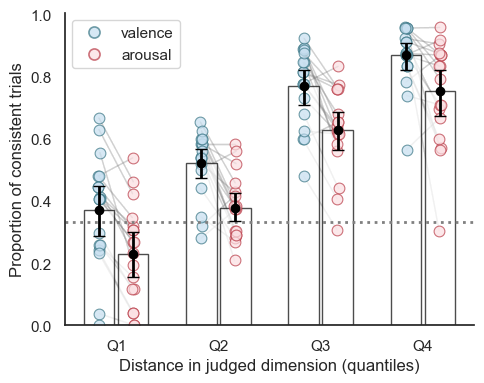

In [13]:
breakdown_to_plot = breakdown_df[breakdown_df['source'] == 'subavg'].groupby(['threshold','subject','modality','consistency','outscan_change_range','comparison_type']).agg({'count': 'sum'}).reset_index()
breakdown_to_plot = breakdown_to_plot.groupby(['threshold','subject','consistency','outscan_change_range','comparison_type']).agg({'count': 'sum'}).reset_index()

consistency_pivot = (breakdown_to_plot.pivot_table(index=['subject', 'outscan_change_range','comparison_type'],columns='consistency',values='count',fill_value=0,aggfunc='sum').reset_index())
consistency_pivot.columns.name = None
consistency_pivot['diff'] = consistency_pivot.get('consistent', 0) - consistency_pivot.get('inconsistent', 0)
consistency_pivot['sum'] = consistency_pivot.get('consistent', 0) + consistency_pivot.get('inconsistent', 0)
consistency_pivot['diff_ratio'] = consistency_pivot['diff'] / consistency_pivot['sum']
consistency_pivot['ratio'] = consistency_pivot.get('consistent', 0) / consistency_pivot.get('sum', 0)
consistency_pivot


stats_df = bootstrap_ci(consistency_pivot, target_col='ratio', group_vars=['outscan_change_range','comparison_type'])
consistency_pivot['comparison_type'] = pd.Categorical(consistency_pivot['comparison_type'], categories=['PLEASANTNESS', 'ACTIVATION'], ordered=True)
plot_subjectConnected_performance_scatter_wbox_nested(
        consistency_pivot,'outscan_change_range','comparison_type','ratio','subject',stats_df,
        outer_order=['Q1', 'Q2', 'Q3', 'Q4'], outer_labels=['Q1', 'Q2', 'Q3', 'Q4'],
        inner_order=['PLEASANTNESS', 'ACTIVATION'], inner_labels=['valence', 'arousal'],
        inner_colors=['#C7DFF0','#FBDFE2'], inner_edgecolors=['#377483','#B83945'],
        connect_subjects=True, line_alpha=0.05,
        plot_box=False, box_edgecolor='lightgray', box_fillcolors=None,
        plot_bar=True, errorbar_color='black',bar_fillcolors='white',bar_edgecolors='black',bar_width=0.6,
        plot_scatter=True, plot_ci=True,dotted_yline=1/3,
        figsize=(5,4), title=None, ylabel='Proportion of consistent trials',
        xlabel='Distance in judged dimension (quantiles)', legend_loc='upper right', legend_bbox_to_anchor=(0.3, 1),
        jitter=0.02, legend=True, legend_title=None, 
        save_svg=True,
        save='./outputs/vector_plots/consistency_trial_ratios_byComparisonType_bothModalities_subavg.svg')
breakdown_to_plot = breakdown_df[breakdown_df['source'] == 'subavg'].groupby(['threshold','subject','modality','consistency','comparison_type']).agg({'count': 'sum'}).reset_index()
breakdown_to_plot = breakdown_to_plot.groupby(['threshold','subject','consistency','comparison_type']).agg({'count': 'sum'}).reset_index()

consistency_pivot = (breakdown_to_plot.pivot_table(index=['subject','comparison_type'],columns='consistency',values='count',fill_value=0,aggfunc='sum').reset_index())
consistency_pivot.columns.name = None
consistency_pivot['diff'] = consistency_pivot.get('consistent', 0) - consistency_pivot.get('inconsistent', 0)
consistency_pivot['sum'] = consistency_pivot.get('consistent', 0) + consistency_pivot.get('inconsistent', 0)
consistency_pivot['diff_ratio'] = consistency_pivot['diff'] / consistency_pivot['sum']
consistency_pivot['ratio'] = consistency_pivot.get('consistent', 0) / consistency_pivot.get('sum', 0)
consistency_pivot
# print range, median, iqr of ratio for each comparison_type
for comp, group in consistency_pivot.groupby('comparison_type'):
    r = group['ratio']
    print(f"Comparison type: {comp}")
    print(f"  Range: {r.min()} - {r.max()}")
    print(f"  Median: {r.median()}")
    print(f"  IQR: {r.quantile(0.75)} - {r.quantile(0.25)} = {(r.quantile(0.75)-r.quantile(0.25))}")


### Stability

In [ ]:
subjects = ['0001', '0002', '0003', '0004','0006','0007','0008','0009','0010', '0011', '0012','0013','0015','0016','0018','0019','0021']
avg_face_data = pd.read_csv('./data/beh/behTables_singleStim/subAvg_table_face_singleStim.csv')
avg_word_data = pd.read_csv('./data/beh/behTables_singleStim/subAvg_table_word_singleStim.csv')
variables = ['v', 'a', 'hap', 'fear', 'sad', 'surprise', 'anger', 'neutral', 'disgust']
#change {modality}_{variable}_slider.response_mean to {variable}
avg_face_data.rename(columns={'face_v_slider.response_mean': 'v', 'face_a_slider.response_mean': 'a', 'face_hap_slider.response_mean': 'hap', 'face_fear_slider.response_mean': 'fear', 'face_sad_slider.response_mean': 'sad', 'face_surprise_slider.response_mean': 'surprise', 'face_anger_slider.response_mean': 'anger', 'face_neutral_slider.response_mean': 'neutral', 'face_disgust_slider.response_mean': 'disgust', 'face': 'stim'}, inplace=True)
avg_word_data.rename(columns={'word_v_slider.response_mean': 'v', 'word_a_slider.response_mean': 'a', 'word_hap_slider.response_mean': 'hap', 'word_fear_slider.response_mean': 'fear', 'word_sad_slider.response_mean': 'sad', 'word_surprise_slider.response_mean': 'surprise', 'word_anger_slider.response_mean': 'anger', 'word_neutral_slider.response_mean': 'neutral', 'word_disgust_slider.response_mean': 'disgust', 'word': 'stim'}, inplace=True)
avg_both_data = pd.concat([avg_face_data, avg_word_data])

#### First-order 

In [24]:
avgspec_corr = []

modalities = {
    "face": {
        "file": "./data/beh/behTables_singleStim/sub{sid}/sub{sid}_table_face_singleStim.csv",
        "avg": avg_face_data,
        "rename": dict(zip(
            ['face_v_slider.response_mean','face_a_slider.response_mean','face_hap_slider.response_mean','face_fear_slider.response_mean','face_sad_slider.response_mean','face_surprise_slider.response_mean','face_anger_slider.response_mean','face_neutral_slider.response_mean','face_disgust_slider.response_mean','face'],
            ['v','a','hap','fear','sad','surprise','anger','neutral','disgust','stim']))},
    "word": {
        "file": "./data/beh/behTables_singleStim/sub{sid}/sub{sid}_table_word_singleStim.csv",
        "avg": avg_word_data,
        "rename": dict(zip(
            ['word_v_slider.response_mean','word_a_slider.response_mean','word_hap_slider.response_mean','word_fear_slider.response_mean','word_sad_slider.response_mean','word_surprise_slider.response_mean','word_anger_slider.response_mean','word_neutral_slider.response_mean','word_disgust_slider.response_mean','word'],
            ['v','a','hap','fear','sad','surprise','anger','neutral','disgust','stim']))}}

for variable in variables:
    for subject in subjects:

        data = {}
        for m, mod in modalities.items():
            df = pd.read_csv(mod["file"].format(sid=subject)).rename(columns=mod["rename"])
            df = df.sort_values("stim").reset_index(drop=True)
            data[m] = df

        data["both"] = pd.concat([data["face"], data["word"]]).sort_values("stim").reset_index(drop=True)

        for m, sub_df in data.items():
            avg_df = avg_both_data if m == "both" else modalities[m]["avg"]

            avg_df = avg_df[avg_df["stim"].isin(sub_df["stim"])].sort_values("stim").reset_index(drop=True)
            sub_df = sub_df[sub_df["stim"].isin(avg_df["stim"])].sort_values("stim").reset_index(drop=True)

            valid = ~sub_df[variable].isna()
            sub_df = sub_df.loc[valid]
            avg_df = avg_df.loc[valid]

            corr = np.corrcoef(sub_df[variable], avg_df[variable])[0, 1]

            avgspec_corr.append({"subject": subject,"variable": variable,"modality": m,"corr": corr})
            if variable not in ['v', 'a']:
                avgspec_corr.append({"subject": subject,"variable": "category", "modality": m, "corr": corr})

avgspec_corr = pd.DataFrame(avgspec_corr)
#get average across category variables and call it category in variable column (basically adding a variable for the average)
avgspec_corr = avgspec_corr.groupby(["subject","variable","modality"]).agg({"corr":"mean"}).reset_index()

print(avgspec_corr.groupby(["variable","modality"]).agg({"corr":["mean","std","min","max"]}))


                       corr                              
                       mean       std       min       max
variable modality                                        
a        both      0.695979  0.138999  0.331583  0.851376
         face      0.763449  0.126410  0.518114  0.922380
         word      0.679428  0.133698  0.276547  0.813622
anger    both      0.767405  0.062486  0.623365  0.846623
         face      0.807518  0.071112  0.654404  0.892280
         word      0.757764  0.077189  0.613196  0.863821
category both      0.775372  0.073819  0.625750  0.849586
         face      0.790169  0.106843  0.479885  0.883814
         word      0.770323  0.067724  0.653826  0.847670
disgust  both      0.810783  0.074801  0.662938  0.881969
         face      0.848373  0.076552  0.676631  0.925266
         word      0.791972  0.073214  0.660942  0.883268
fear     both      0.754441  0.058467  0.652075  0.855688
         face      0.647435  0.164208  0.256011  0.844143
         word 

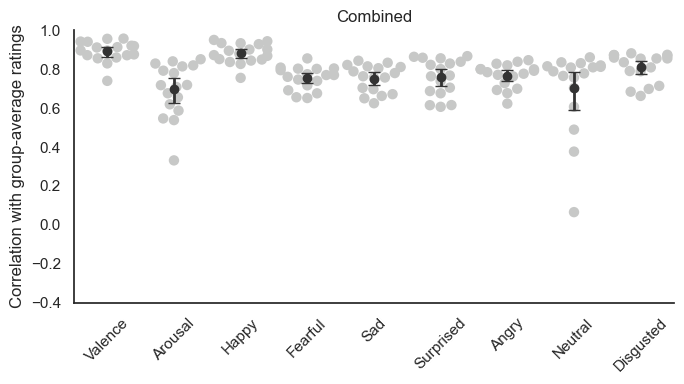

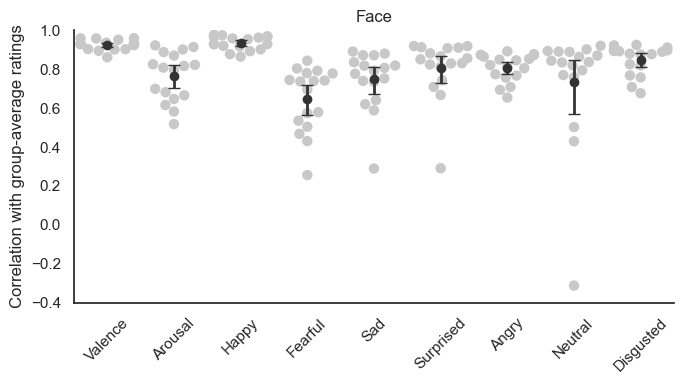

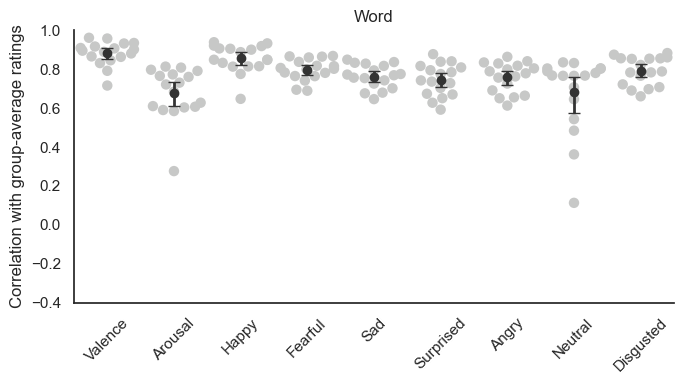

In [ ]:
for i, (modality, modality_name) in enumerate([('both','Combined'),('face','Face'),('word','Word')]):
    avgspec_corr_mod = avgspec_corr[avgspec_corr['modality'] == modality]
    avgspec_corr_mod = avgspec_corr_mod[avgspec_corr_mod['variable'] != 'category']
    stats_df = bootstrap_ci(avgspec_corr_mod, 'corr', ['variable'])
    plot_subjectConnected_performance_scatter_wbox(avgspec_corr_mod,'variable','corr','subject',stats_df,
                condition_order=['v', 'a', 'hap', 'fear', 'sad', 'surprise', 'anger', 'neutral', 'disgust'], condition_labels=['Valence', 'Arousal', 'Happy', 'Fearful', 'Sad', 'Surprised', 'Angry', 'Neutral', 'Disgusted'],
                fill_colors=['#c7c8c7']*9,edge_colors=['black']*9,connect_subjects=False,line_alpha=0.07,
                plot_box=True, box_edgecolor='white',box_fillcolors=None,
                plot_bar=False,bar_width=0.7,bar_gap=0.05,errorbar_color='#333333',
                plot_scatter=True,title=modality_name,
                figsize=(7,4), ylabel='Correlation with group-average ratings',legend=False,
                xlabel='', yrange=(-0.4,1), dotted_yline=None, solid_yline=None, jitter=0.02, ax=None,
                xlabel_angle=45, density_scaled_jitter=True,
                save_svg=True,
                save=f'./outputs/vector_plots/1storder_avgspec_corr_{modality}.svg')


In [21]:
import pingouin as pg
all_icc = pd.DataFrame()
for variable in variables:
    ratings = {'both':[],'face':[],'word':[]}  

    for subject in subjects:
        sub_data_face = pd.read_csv(f'./data/beh/behTables_singleStim/sub{subject}/sub{subject}_table_face_singleStim.csv')
        sub_data_word = pd.read_csv(f'./data/beh/behTables_singleStim/sub{subject}/sub{subject}_table_word_singleStim.csv')
        sub_data_face.rename(columns={'face_v_slider.response_mean': 'v', 'face_a_slider.response_mean': 'a', 'face_hap_slider.response_mean': 'hap', 'face_fear_slider.response_mean': 'fear', 'face_sad_slider.response_mean': 'sad', 'face_surprise_slider.response_mean': 'surprise', 'face_anger_slider.response_mean': 'anger', 'face_neutral_slider.response_mean': 'neutral', 'face_disgust_slider.response_mean': 'disgust', 'face': 'stim'}, inplace=True)
        sub_data_word.rename(columns={'word_v_slider.response_mean': 'v', 'word_a_slider.response_mean': 'a', 'word_hap_slider.response_mean': 'hap', 'word_fear_slider.response_mean': 'fear', 'word_sad_slider.response_mean': 'sad', 'word_surprise_slider.response_mean': 'surprise', 'word_anger_slider.response_mean': 'anger', 'word_neutral_slider.response_mean': 'neutral', 'word_disgust_slider.response_mean': 'disgust', 'word': 'stim'}, inplace=True)
        sub_data_both = pd.concat([sub_data_face[['stim',variable]], sub_data_word[['stim',variable]]])
        for _, row in sub_data_both.iterrows():
            ratings['both'].append({'stim': row['stim'], 'modality': 'both', 'subject': subject, 'rating': row[variable]})
        for _, row in sub_data_face.iterrows():
            ratings['face'].append({'stim': row['stim'], 'modality': 'face', 'subject': subject, 'rating': row[variable]})
        for _, row in sub_data_word.iterrows():
            ratings['word'].append({'stim': row['stim'], 'modality': 'word', 'subject': subject, 'rating': row[variable]})
    for modality in ['both','face','word']:
        df_long = pd.DataFrame(ratings[modality]).dropna()
        icc = pg.intraclass_corr(data=df_long, targets='stim', raters='subject',ratings='rating',  nan_policy='omit')
        icc['variable'] = variable
        icc['modality'] = modality
        all_icc = pd.concat([all_icc, icc])
print(all_icc.to_string())


    Type              Description       ICC           F  df1   df2           pval         CI95%  variable modality
0   ICC1   Single raters absolute  0.744174   50.451448  124  2000   0.000000e+00  [0.69, 0.79]         v     both
1   ICC2     Single random raters  0.744243   51.373134  124  1984   0.000000e+00  [0.69, 0.79]         v     both
2   ICC3      Single fixed raters  0.747674   51.373134  124  1984   0.000000e+00    [0.7, 0.8]         v     both
3  ICC1k  Average raters absolute  0.980179   50.451448  124  2000   0.000000e+00  [0.97, 0.98]         v     both
4  ICC2k    Average random raters  0.980186   51.373134  124  1984   0.000000e+00  [0.97, 0.98]         v     both
5  ICC3k     Average fixed raters  0.980535   51.373134  124  1984   0.000000e+00  [0.98, 0.99]         v     both
0   ICC1   Single raters absolute  0.841384   91.177099   20   336  1.505645e-122  [0.75, 0.92]         v     face
1   ICC2     Single random raters  0.841555  103.093942   20   320  2.258580e-12

In [99]:
all_icc[all_icc['Type'] == 'ICC2k']
to_merge = avgspec_corr.groupby(["variable","modality"]).agg({"corr":["mean","std","min","max"]}).reset_index()
to_merge = to_merge[to_merge['variable'] != 'category'].reset_index(drop=True)
#change the grouped column names to mean, std, min, max
to_merge.columns = ['variable','modality','mean','std','min','max']
#merge all_icc and avgspec_corr on variable and modality
avgspec_corr_stats = pd.merge(to_merge,
                              all_icc[all_icc['Type'] == 'ICC2k'][['variable','modality','ICC','CI95%']].reset_index(), 
                              on=['variable','modality'], how='left')
#remove the index column
avgspec_corr_stats = avgspec_corr_stats.drop(columns=['index'])
#rename variable (v: valence, a: arousal, hap: happy, fear: fearful, sad: sad, surprise: surprised, anger: angry, neutral: neutral, disgust: disgusted)
avgspec_corr_stats['variable'] = avgspec_corr_stats['variable'].map({'v': 'valence', 'a': 'arousal', 'hap': 'happy', 'fear': 'fearful', 'sad': 'sad', 'surprise': 'surprised', 'anger': 'angry', 'neutral': 'neutral', 'disgust': 'disgusted'})
#order of variables: valence, arousal, happy, fearful, sad, surprised, angry, neutral, disgusted
avgspec_corr_stats['variable'] = pd.Categorical(avgspec_corr_stats['variable'], categories=['valence', 'arousal', 'happy', 'fearful', 'sad', 'surprised', 'angry', 'neutral', 'disgusted'], ordered=True)
#sort by modality and variable
avgspec_corr_stats = avgspec_corr_stats.sort_values(by=['modality','variable']).reset_index(drop=True)
#make all values 2 decimal places
avgspec_corr_stats = avgspec_corr_stats.round(2)
#add a comma between the lower and upper CI
avgspec_corr_stats['CI95%'] = avgspec_corr_stats['CI95%'].apply(lambda x: f"{x[0]:.2f}, {x[1]:.2f}")
#capitalize the first letter of the modality and variable
avgspec_corr_stats['modality'] = avgspec_corr_stats['modality'].str.capitalize()
avgspec_corr_stats['variable'] = avgspec_corr_stats['variable'].str.capitalize()
avgspec_corr_stats.to_csv('./outputs/1storder_avgspec_corr_stats.csv', index=False)

#### Second-order & MDS

In [7]:
def procrustes_stats(rating_df,categories,modality, cate_name_map, random_state=42):
    rating_df = rating_df.copy()
    rating_df['max_category'] = rating_df['max_category'].map(cate_name_map)

    rating_cols = [f'{modality}_{cat}_slider.response_mean' for cat in categories]
    X = rating_df[rating_cols].values
    valid_mask = ~np.isnan(X).any(axis=1)
    rating_df = rating_df[valid_mask]

    dissimilarity = pairwise_distances(X, metric='cosine')
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=random_state)
    coords = mds.fit_transform(dissimilarity)


    va = rating_df[[f'{modality}_v_slider.response_mean',f'{modality}_a_slider.response_mean']].values
    coords = [[coords[i, 0], coords[i, 1]] for i in range(len(coords))]

    observed, perm, p = procrustes_alignment_test(coords, va, rating_df['max_category'].values, n_permutations=100000, shuffle_within_category=False)
    print(f"Observed Procrustes distance = {observed:.3f}")
    print(f"Mean shuffled distance = {perm.mean():.3f} ± {perm.std():.3f}")
    print(f"p = {p:.4f}")

In [8]:

def compute_va_rdm(df):
    X = df[['v', 'a']].values
    return pairwise_distances(X, metric='euclidean')

def compute_category_rdm(df, category_vars):
    X = df[category_vars].values
    return pairwise_distances(X, metric='cosine') 

def mantel_test(D1, D2, n_permutations=10000, random_state=42,method='spearman'):
    D1 = np.asarray(D1)
    D2 = np.asarray(D2)
    assert D1.shape == D2.shape, "Distance matrices must have the same shape for Mantel test."
    assert D1.shape[0] == D1.shape[1], "D1 is not square."
    assert D2.shape[0] == D2.shape[1], "D2 is not square."

    n = D1.shape[0]
    iu = np.triu_indices(n, k=1)
    v1 = D1[iu]
    v2 = D2[iu]

    #remove nans
    mask = ~np.isnan(v1) & ~np.isnan(v2)
    v1 = v1[mask]
    v2 = v2[mask]


    r_obs = np.corrcoef(v1, v2)[0, 1] if method == 'pearson' else spearmanr(v1, v2)[0]
    rng = np.random.default_rng(random_state)
    perm_rs = np.empty(n_permutations)
    for i in range(n_permutations):
        perm = rng.permutation(len(v2))
        perm_rs[i] = np.corrcoef(v1, v2[perm])[0, 1] if method == 'pearson' else spearmanr(v1, v2[perm])[0]

    #two-sided p-value
    p = (np.sum(np.abs(perm_rs) >= np.abs(r_obs)) + 1) / (n_permutations + 1)

    return r_obs, p, perm_rs

def load_subject_modality_df(subject, modality, rating_vars):
    path = f'./data/beh/behTables_singleStim/sub{subject}/sub{subject}_table_{modality}_singleStim.csv'
    df = pd.read_csv(path)
    df = rename_rating_columns(df, modality, rating_vars)
    return df

def align_subject_and_group(sub_df, group_df):
    group_df_sub = group_df[group_df['stim'].isin(sub_df['stim'])].copy()

    sub_sorted = sub_df.sort_values(by='stim').reset_index(drop=True)
    group_sorted = group_df_sub.sort_values(by='stim').reset_index(drop=True)
    assert sub_sorted['stim'].equals(group_sorted['stim'])
    return sub_sorted, group_sorted

def filter_valid_rows_for_type(sub_df, group_df, rating_type, category_vars):
    if rating_type == 'va':
        cols = ['v', 'a']
    elif rating_type == 'category':
        cols = category_vars
    else:
        raise ValueError("rating_type must be 'va' or 'category'.")

    sub_vals = sub_df[cols].values
    grp_vals = group_df[cols].values

    mask = (~np.isnan(sub_vals).any(axis=1)) & (~np.isnan(grp_vals).any(axis=1))
    return sub_df.loc[mask].reset_index(drop=True), group_df.loc[mask].reset_index(drop=True)

def compute_second_order_stability(subjects, avg_face_data, avg_word_data, category_vars, rating_vars, n_permutations=10000, random_state=42):
    rows = []

    avg_both_data = pd.concat([avg_face_data, avg_word_data], ignore_index=True)

    for subj in subjects:
        for modality in ['face', 'word', 'both']:

            if modality in ['face', 'word']:
                group_df = avg_face_data if modality == 'face' else avg_word_data

                sub_df = load_subject_modality_df(subj, modality, rating_vars)
                sub_aligned, grp_aligned = align_subject_and_group(sub_df, group_df)

            elif modality == 'both':
                sub_face = load_subject_modality_df(subj, 'face', rating_vars)
                sub_word = load_subject_modality_df(subj, 'word', rating_vars)
                sub_both = pd.concat([sub_face, sub_word], ignore_index=True)
                sub_aligned, grp_aligned = align_subject_and_group(sub_both, avg_both_data)

            for rating_type in ['va', 'category']:
                sub_clean, grp_clean = filter_valid_rows_for_type(sub_aligned, grp_aligned, rating_type, category_vars)

                if rating_type == 'va':
                    sub_rdm = compute_va_rdm(sub_clean)
                    grp_rdm = compute_va_rdm(grp_clean)
                else:
                    sub_rdm = compute_category_rdm(sub_clean, category_vars)
                    grp_rdm = compute_category_rdm(grp_clean, category_vars)

                r, p, perm = mantel_test(sub_rdm, grp_rdm,n_permutations=n_permutations,random_state=random_state)
                rows.append({'subject': subj,'modality': modality,'rating_type': rating_type,'mantel_r': r,'mantel_p': p,'n_stimuli': len(sub_clean)})

    return pd.DataFrame(rows)

def rename_rating_columns(df, modality, rating_vars):
    rename_dict = {f'{modality}_{var}_slider.response_mean': var for var in rating_vars}
    rename_dict[modality] = 'stim'
    return df.rename(columns=rename_dict)

In [9]:
subjects = ['0001', '0002', '0003', '0004','0006','0007','0008','0009','0010', '0011', '0012','0013','0015','0016','0018','0019','0021']
rating_vars = ['v', 'a', 'hap', 'fear', 'sad', 'surprise', 'anger', 'neutral', 'disgust']
category_vars = ['hap', 'fear', 'sad', 'surprise', 'anger', 'neutral', 'disgust']
#load group-average data
avg_face_data = pd.read_csv('./data/beh/behTables_singleStim/subAvg_table_face_singleStim.csv')
avg_word_data = pd.read_csv('./data/beh/behTables_singleStim/subAvg_table_word_singleStim.csv')
avg_face_data = rename_rating_columns(avg_face_data, 'face', rating_vars)
avg_word_data = rename_rating_columns(avg_word_data, 'word', rating_vars)
avg_both_data = pd.concat([avg_face_data, avg_word_data]).reset_index(drop=True)
second_order_stability = compute_second_order_stability(subjects, avg_face_data,avg_word_data, category_vars,rating_vars, n_permutations=10,random_state=42)

print("Second-order group–individual stability (Mantel):")
#print(second_order_stability.to_string())
print(second_order_stability.groupby(['modality', 'rating_type'])['mantel_r'].agg(['mean', 'std', 'min', 'max']))

Second-order group–individual stability (Mantel):
                          mean       std       min       max
modality rating_type                                        
both     category     0.649771  0.105604  0.424085  0.786887
         va           0.672308  0.103292  0.491345  0.815431
face     category     0.719199  0.072718  0.587970  0.812846
         va           0.739779  0.077958  0.593640  0.867846
word     category     0.628207  0.109654  0.447762  0.785271
         va           0.661527  0.112708  0.462766  0.854327


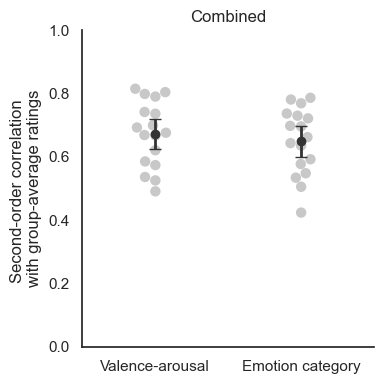

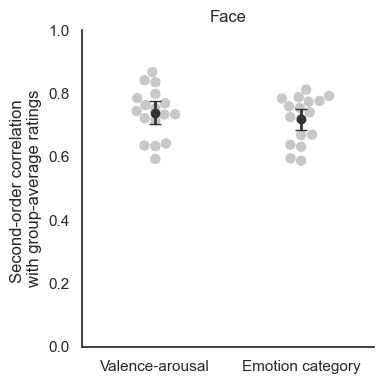

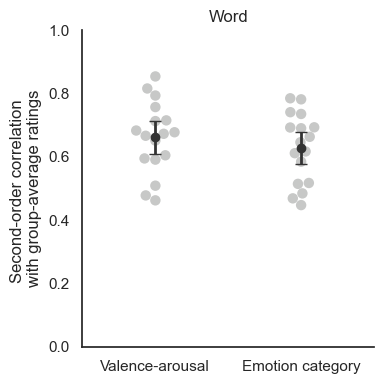

In [ ]:
for i, (modality, modality_name) in enumerate([('both','Combined'),('face','Face'),('word','Word')]):
    second_order_stability_mod = second_order_stability[second_order_stability['modality'] == modality]
    stats_df = bootstrap_ci(second_order_stability_mod, 'mantel_r', ['rating_type'])
    plot_subjectConnected_performance_scatter_wbox(second_order_stability_mod,'rating_type','mantel_r','subject',stats_df,
                condition_order=['va', 'category'], condition_labels=['Valence-arousal', 'Emotion category'],
                fill_colors=['#c7c8c7']*9,edge_colors=['black']*9,connect_subjects=False,line_alpha=0.07,
                plot_box=True, box_edgecolor='white',box_fillcolors=None,
                plot_bar=False,bar_width=0.7,bar_gap=0.05,errorbar_color='#333333',
                plot_scatter=True,title=modality_name,
                figsize=(4,4), ylabel='Second-order correlation \nwith group-average ratings',legend=False,
                xlabel='', yrange=(0, 1), dotted_yline=None, solid_yline=None, jitter=0.02, ax=None,
                xlabel_angle=0, density_scaled_jitter=True,
                save_svg=True,
                save=f'./outputs/vector_plots/2ndorder_avgspec_corr_{modality}.svg')

In [118]:
#save the second_order_stability dataframe after renaming the columns
to_save = second_order_stability.groupby(['modality', 'rating_type'])['mantel_r'].agg(['mean', 'std', 'min', 'max']).reset_index()
to_save.columns = ['modality', 'rating_type', 'mean', 'std', 'min', 'max']
to_save['rating_type'] = to_save['rating_type'].map({'va': 'Valence-arousal', 'category': 'Emotion category'})
to_save['modality'] = to_save['modality'].str.capitalize()
to_save['rating_type'] = to_save['rating_type'].str.capitalize()
to_save = to_save.round(2)
to_save.to_csv('./outputs/2ndorder_avgspec_corr_stats.csv', index=False)

#### Cross-modality

In [52]:
import ot
from sklearn.preprocessing import StandardScaler

def zscore_va(df):
    df = df.copy()
    df[['v', 'a']] = StandardScaler().fit_transform(df[['v', 'a']])
    return df

def va_distance_matrix(df):
    X = df[['v', 'a']].dropna().values
    return pairwise_distances(X, metric='euclidean')

def category_distance_matrix(df, category_vars):
    X = df[category_vars].dropna().values
    return pairwise_distances(X, metric='cosine')

def gromov_wasserstein_distance(D1, D2, loss_fun='square_loss'):
    n, m = D1.shape[0], D2.shape[0]

    # Uniform distributions on points
    p = np.ones(n) / n
    q = np.ones(m) / m

    # Compute GW transport and loss
    gw_plan, log = ot.gromov.gromov_wasserstein(D1, D2, p, q, loss_fun=loss_fun, log=True)

    # store loss
    gw_dist = log["gw_dist"]

    return gw_dist, gw_plan

def gw_permutation_test(D1, D2, n_perm=100, random_state=42):
    rng = np.random.default_rng(random_state)
    null_dists = []

    for i in range(n_perm):
        perm = rng.permutation(D2.shape[0])
        D2_perm = D2[perm][:, perm]

        gw_dist, _ = gromov_wasserstein_distance(D1, D2_perm)
        null_dists.append(gw_dist)

    return np.array(null_dists)
    
def randomize_va_geometry(df):
    df_rand = df.copy()
    df_rand['v'] = np.random.permutation(df_rand['v'].values)
    df_rand['a'] = np.random.permutation(df_rand['a'].values)
    return df_rand
def randomize_category_geometry(df):
    df_rand = df.copy()
    df_rand[category_vars] = np.random.permutation(df_rand[category_vars].values)
    return df_rand
def gw_random_geometry_test(avg_face_data, avg_word_data, n_perm=200):
    null_va = []

    for i in range(n_perm):
        # Randomize VA geometry of word stimuli
        word_rand = randomize_va_geometry(avg_word_data)

        D_face_va = va_distance_matrix(avg_face_data)
        D_word_va_rand = va_distance_matrix(word_rand)

        gw_va, _ = gromov_wasserstein_distance(D_face_va, D_word_va_rand)
        null_va.append(gw_va)

    return np.array(null_va)

avg_face_data_z = zscore_va(avg_face_data)
avg_word_data_z = zscore_va(avg_word_data)
D_face_va = va_distance_matrix(avg_face_data_z)
D_word_va = va_distance_matrix(avg_word_data_z)

gw_va_dist, gw_va_plan = gromov_wasserstein_distance(D_face_va, D_word_va)

print(f"Gromov-Wasserstein distance (VA, face vs word): {gw_va_dist:.4f}")

category_vars = ['hap', 'fear', 'sad', 'surprise', 'anger', 'neutral', 'disgust']

D_face_cat = category_distance_matrix(avg_face_data, category_vars)
D_word_cat = category_distance_matrix(avg_word_data, category_vars)

gw_cat_dist, gw_cat_plan = gromov_wasserstein_distance(D_face_cat, D_word_cat)

print(f"Gromov-Wasserstein distance (Categories, face vs word): {gw_cat_dist:.4f}")
n_perm = 10000
null_va = gw_random_geometry_test(randomize_va_geometry(avg_face_data), avg_word_data, n_perm=n_perm)
null_cat = gw_random_geometry_test(randomize_category_geometry(avg_face_data), avg_word_data, n_perm=n_perm)

print("VA null mean:", null_va.mean())
print("Category null mean:", null_cat.mean())

p_va = (np.sum(null_va <= gw_va_dist) + 1) / (n_perm + 1)
p_cat = (np.sum(null_cat <= gw_cat_dist) + 1) / (n_perm + 1)

print("VA GW p-value:", p_va)
print("Category GW p-value:", p_cat)



Gromov-Wasserstein distance (VA, face vs word): 0.1857
Gromov-Wasserstein distance (Categories, face vs word): 0.0073


VA null mean: 0.8956444669912258
Category null mean: 0.9465599396867573
VA GW p-value: 9.999000099990002e-05
Category GW p-value: 9.999000099990002e-05
